# Loan Approval Prediction

## What's Under the Hood?

From raw CSV to production-ready predictions, this pipeline covers the full lifecycle:

- **Exploratory Data Analysis** — uncovering the signals that actually drive approval
- **Feature Engineering** — translating raw financials into meaningful indicators like DTI, EMI, and Balance Income
- **Multi-Model Benchmarking** — Logistic Regression, XGBoost, and Random Forest, head to head
- **Custom SMOTE** — synthetic oversampling built from scratch to handle class imbalance fairly
- **Ensemble Learning** — Soft Voting and Stacking classifiers for robust, combined predictions
- **Hyperparameter Tuning** — Randomized Search over 100 iterations, optimising for ROC-AUC

---

## The Verdict

After rigorous stratified cross-validation, hyperparameter tuning, and held-out test evaluation — the **Stacking Classifier trained on engineered features with SMOTE** emerges as the recommended model: balanced, robust, and built to generalise.

---

## Importing Libraries

All dependencies for the end-to-end binary classification pipeline are loaded here.

| Category | Libraries |
|---|---|
| Data handling | `pandas`, `numpy` |
| Visualisation | `matplotlib`, `seaborn` |
| Preprocessing | `LabelEncoder`, `KNNImputer` |
| Models | `LogisticRegression`, `RandomForestClassifier`, `XGBClassifier` |
| Ensembles | `VotingClassifier`, `StackingClassifier` |
| Validation | `StratifiedKFold`, `cross_validate`, `GridSearchCV`, `RandomizedSearchCV` |
| Metrics | `accuracy_score`, `precision_score`, `recall_score`, `roc_auc_score`, `f1_score`, `confusion_matrix` |
| Sampling | `NearestNeighbors` (custom SMOTE), `scipy.stats.randint/uniform` |

`warnings.filterwarnings('ignore')` suppresses verbose output during cross-validation and fitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier, plot_importance
from scipy.stats import randint, uniform

import warnings 
warnings.filterwarnings('ignore')

## Loading & Initial Exploration

The training CSV is read into a pandas DataFrame where each **row = one loan application** and each **column = a feature or the target**.

```python
df_raw = pd.read_csv('Dataset/train_data.csv')
```

Key inspection steps:

| Method | Purpose |
|---|---|
| `.shape` | Confirms dataset dimensions `(rows, columns)` |
| `.head(5)` | Quick visual scan of values and formatting |
| `.info()` | Shows dtypes — `object` columns need encoding, `float/int` are model-ready |
| `.isnull().sum()` | Counts missing values per column — guides imputation strategy |
| `.describe()` | Summary stats (mean, std, min/max, quartiles) — reveals skewness and outliers |

**Target variable:** `Loan_Status` ∈ {`Y`, `N`} → binary classification task.  
Skewed income features (mean ≫ median) will motivate log-transforms in feature engineering.

In [2]:
df_raw = pd.read_csv('../Dataset/train_data.csv', encoding='utf-8')
print(f"Initial dataset shape: {df_raw.shape}")
print(df_raw.head(5))
print("\n--- DATA TYPES & COLUMN INFO ---")
df_raw.info()
print("\n---MISSING VALUES COUNT---")
print(df_raw.isnull().sum())
print("\n---SUMMARY---")
print(df_raw.describe())

Initial dataset shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural  

## Data Cleaning & Target Encoding

### Steps

**1. Drop `Loan_ID`** — a unique identifier with no predictive signal; keeping it risks spurious correlations.

**2. Fix `Dependents`** — the value `"3+"` is text and breaks numerical ops. Replaced with `3` and cast to `float` (float temporarily allows `NaN` storage).

**3. Auto-detect columns with missing values** using a dynamic loop:
- `dtype == 'object'` or `nunique() < 10` → **categorical** → impute with **mode** (most frequent value)
- `dtype != 'object'` and `nunique() ≥ 10` → **numerical** → impute with **median**

> Median is preferred over mean for financial features because it is robust to the heavy right-skew typical of income/loan-amount distributions.

$$\text{Mode}(X) = \arg\max_x f(x) \qquad \text{Median} = x_{\lfloor(n+1)/2\rfloor}$$

**4. Restore integer dtypes** for `Dependents` and `Credit_History` after imputation.

**5. Encode target:**

$$\text{Loan\_Status}: \; Y \rightarrow 1 \;(\text{Approved}), \quad N \rightarrow 0 \;(\text{Rejected})$$

In [3]:
if 'Loan_ID' in df_raw.columns:
    df_raw.drop('Loan_ID', axis=1, inplace=True)
if 'Dependents' in df_raw.columns:
    df_raw['Dependents'] = df_raw['Dependents'].replace('3+', 3).astype(float)

cat_cols = []
num_cols = []
for col in df_raw.columns:
    if df_raw[col].isnull().sum() > 0:
        if df_raw[col].dtype == 'object' or df_raw[col].nunique() < 10:
            cat_cols.append(col)
        elif df_raw[col].dtype != 'object' and df_raw[col].nunique() >= 10:
            num_cols.append(col)
print(f"Categorical Columns to impute: {cat_cols}")
print(f"Numerical Columns to impute: {num_cols}")

for col in cat_cols:
    df_raw[col] = df_raw[col].fillna(df_raw[col].mode()[0])
for col in num_cols:
    df_raw[col] = df_raw[col].fillna(df_raw[col].median())

train_modes = {col: df_raw[col].mode()[0] for col in cat_cols}
train_medians = {col: df_raw[col].median() for col in num_cols}

if 'Dependents' in df_raw.columns:
    df_raw['Dependents'] = df_raw['Dependents'].astype('Int64')
    
if 'Credit_History' in df_raw.columns:
    df_raw['Credit_History'] = df_raw['Credit_History'].astype('Int64')
df_raw['Loan_Status'] = df_raw['Loan_Status'].map({'Y': 1, 'N': 0})

print("--- MISSING VALUES AFTER CLEANING ---")
print(df_raw.isnull().sum())

Categorical Columns to impute: ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
Numerical Columns to impute: ['LoanAmount', 'Loan_Amount_Term']
--- MISSING VALUES AFTER CLEANING ---
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## Exploratory Data Analysis — Key Signal Check

Three plots assess the most important patterns before deeper analysis:

**Plot 1 — Credit History vs Loan Status (countplot)**  
`Credit_History` is typically the strongest single predictor. The count plot estimates:
$$P(\text{Approved} \mid \text{Credit\_History}=1) \gg P(\text{Approved} \mid \text{Credit\_History}=0)$$

**Plot 2 — Applicant Income Distribution (histogram + KDE)**  
Income is heavily right-skewed (long tail of high earners). KDE smooths the empirical density:
$$\hat{f}(x) = \frac{1}{nh}\sum_{i=1}^{n} K\!\left(\frac{x-x_i}{h}\right)$$
The x-axis is capped at 20 000 to avoid extreme-outlier distortion. This skewness motivates log-transforms later.

**Plot 3 — Loan Amount by Status (boxplot)**  
Shows median, IQR ($Q_3 - Q_1$), and outliers (values beyond $Q_1 - 1.5\,\text{IQR}$ or $Q_3 + 1.5\,\text{IQR}$) for each approval class.

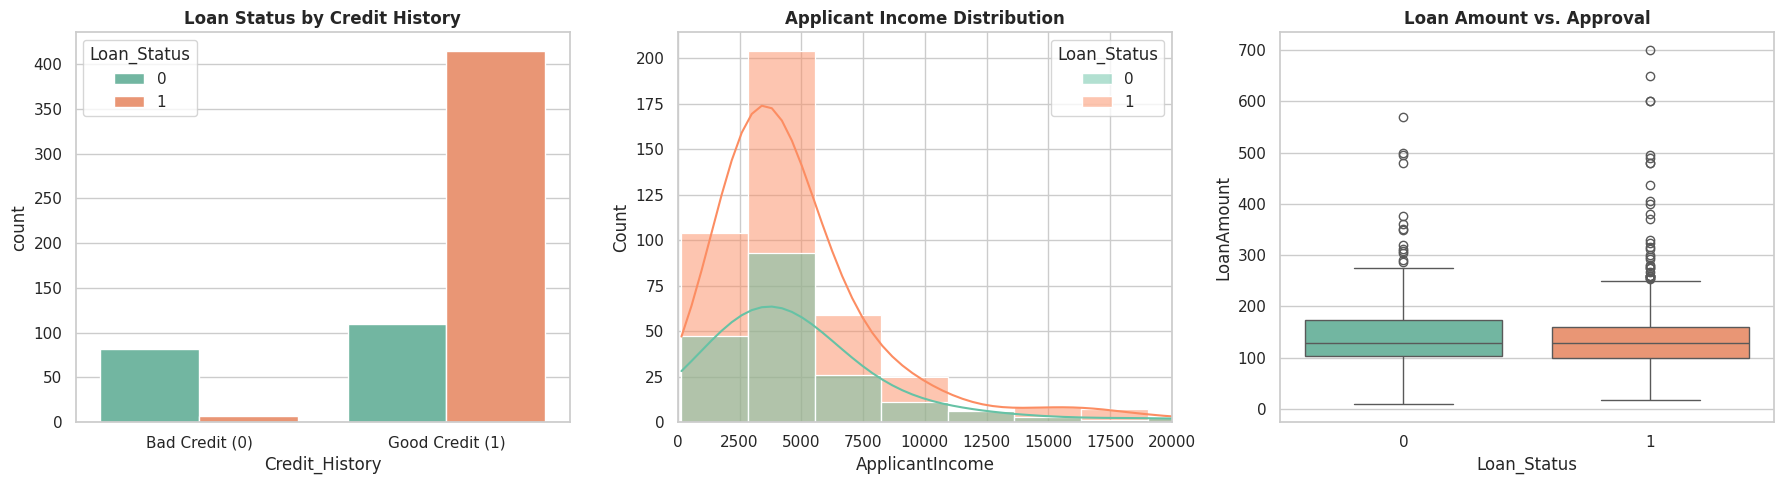

In [4]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The overriding power of Credit History
sns.countplot(ax=axes[0], data=df_raw, x='Credit_History', hue='Loan_Status', palette='Set2')
axes[0].set_title('Loan Status by Credit History', fontweight='bold')
axes[0].set_xticklabels(['Bad Credit (0)', 'Good Credit (1)'])

# Plot 2: Income Distribution (To show why we need Log Transforms or Ratios)
sns.histplot(ax=axes[1], data=df_raw, x='ApplicantIncome', hue='Loan_Status', kde=True, bins=30, palette='Set2')
axes[1].set_title('Applicant Income Distribution', fontweight='bold')
axes[1].set_xlim(0, 20000) # Zoom in to ignore extreme outliers for the plot

# Plot 3: Loan Amount vs. Status (Boxplot)
sns.boxplot(ax=axes[2], data=df_raw, x='Loan_Status', y='LoanAmount', palette='Set2')
axes[2].set_title('Loan Amount vs. Approval', fontweight='bold')

plt.tight_layout()
plt.show()

## Full Exploratory Data Analysis

A comprehensive EDA is run via `run_full_eda(df_raw)`, which calls seven sub-functions:

| Function | What it shows |
|---|---|
| `plot_target` | Class balance — bar + pie chart of approval ratio |
| `plot_num_distributions` | Histograms + boxplots for all numerical features; skewness annotated |
| `plot_log_transform` | Side-by-side raw vs `log1p`-transformed income — justifies the transform |
| `plot_cat_distributions` | Bar counts for all categorical columns |
| `plot_cat_vs_target` | Normalised approval rate (%) per category group |
| `plot_boxplots_vs_target` | Income & loan amount distributions split by approval status |
| `plot_correlation_heatmap` | Lower-triangle Pearson correlation matrix; `Credit_History` expected to show the strongest correlation with `Loan_Status` |

**Log transform used:**
$$y = \log(1 + x)$$
Compresses large values, reduces skew, stabilises variance — especially important for Logistic Regression.

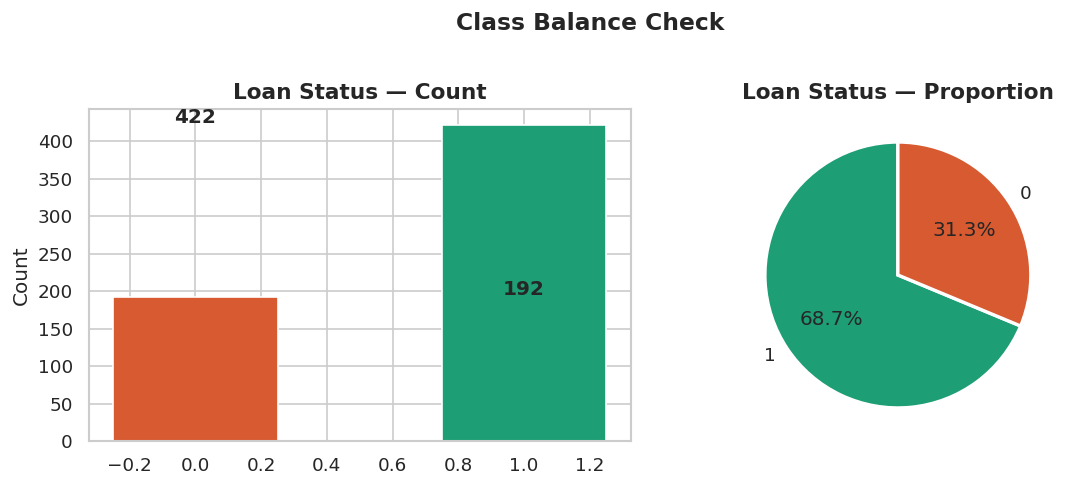

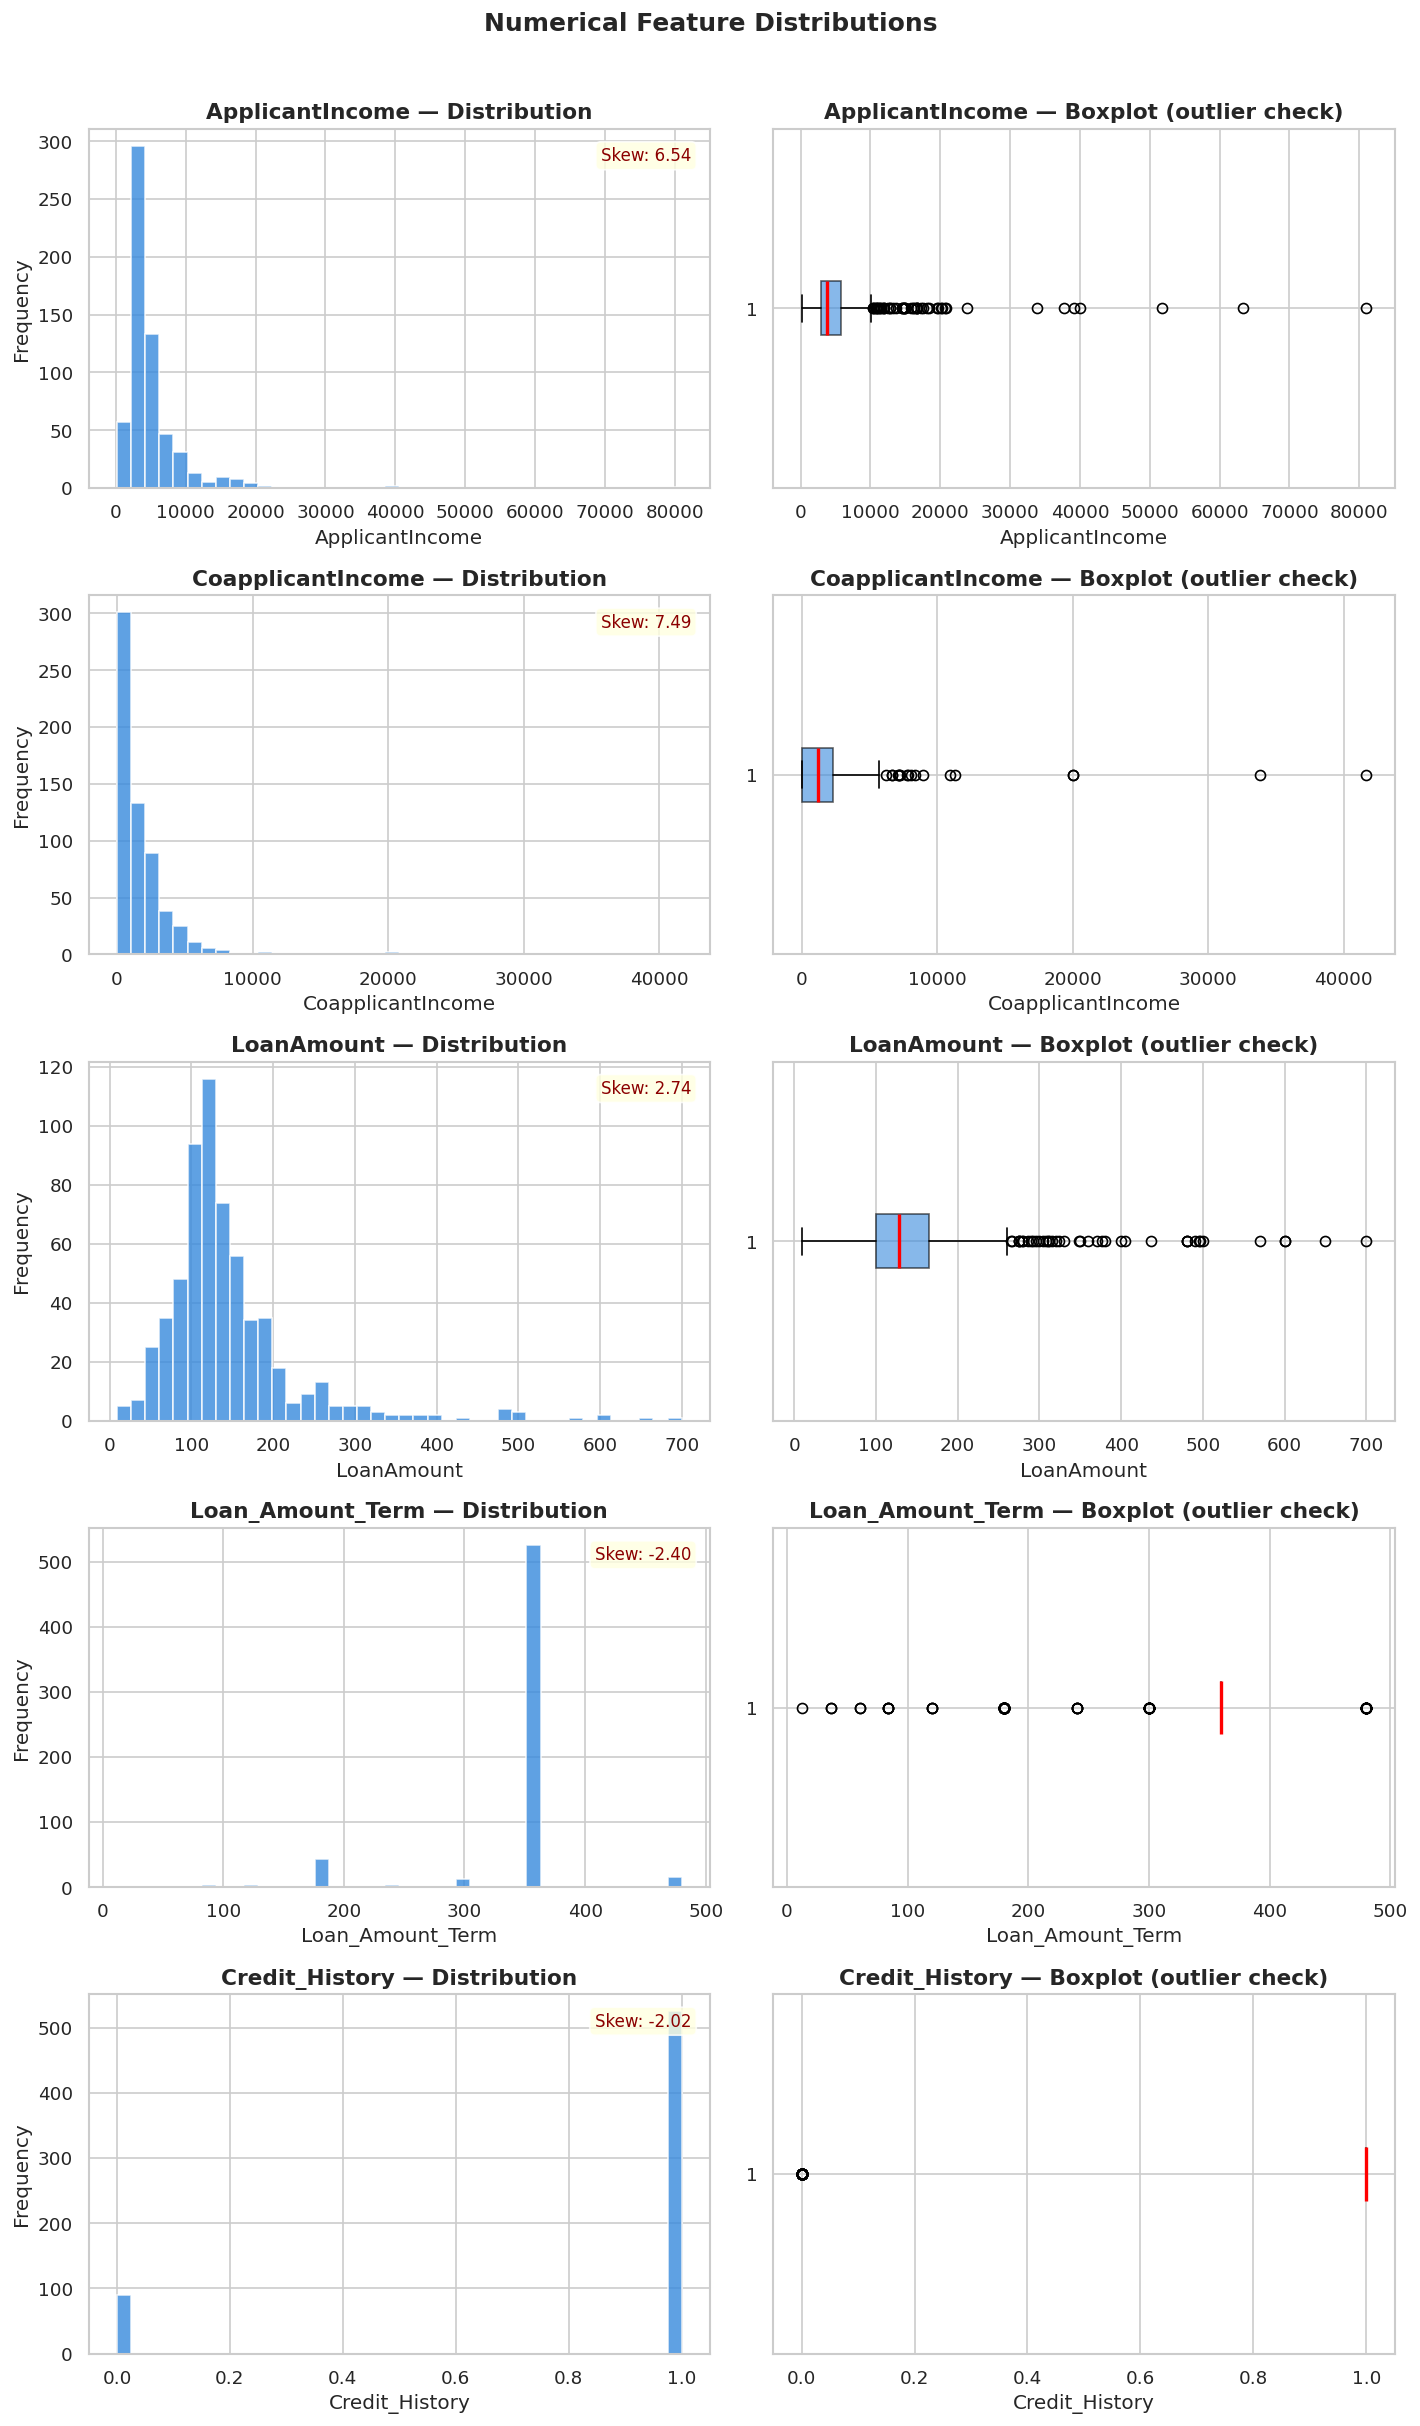

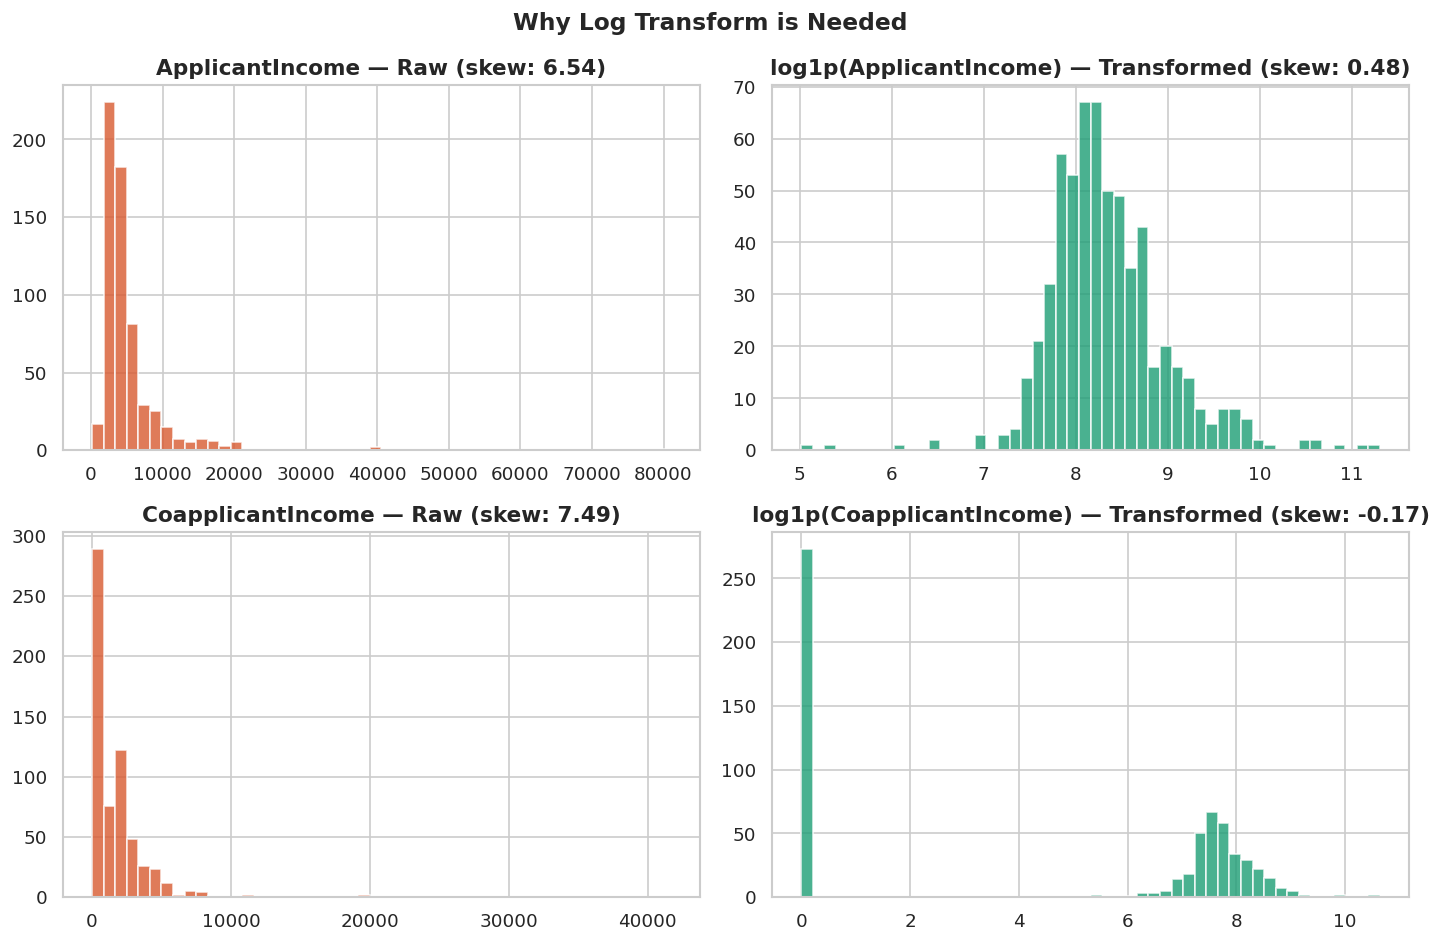

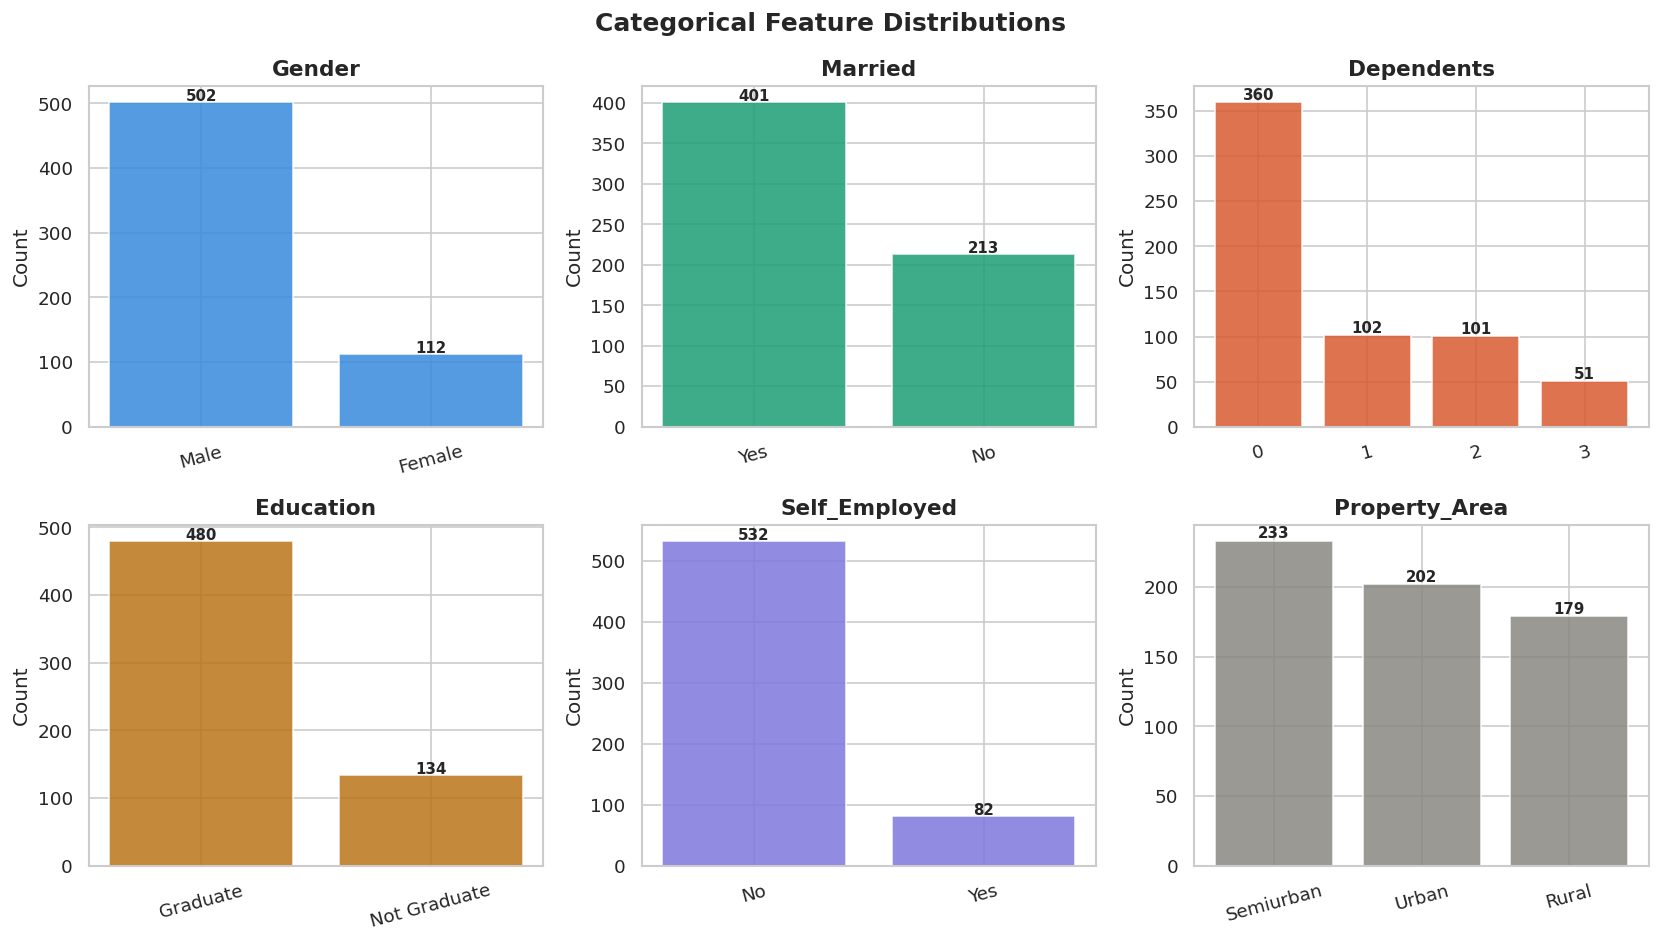

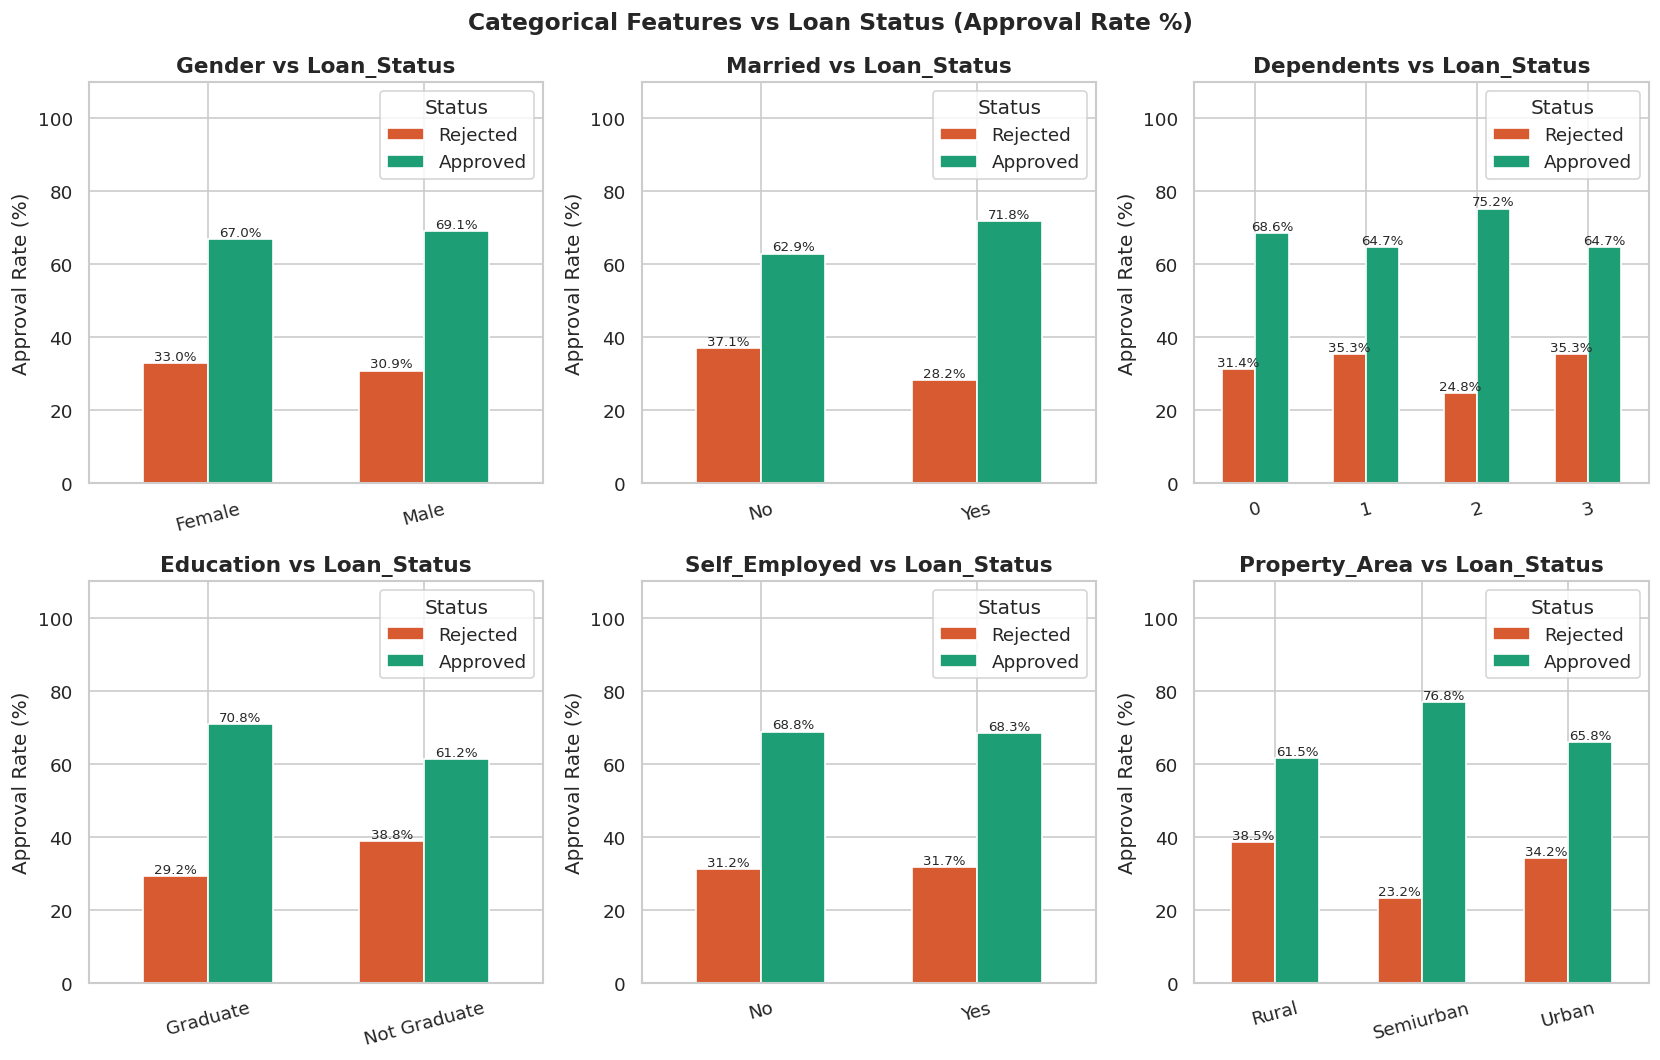

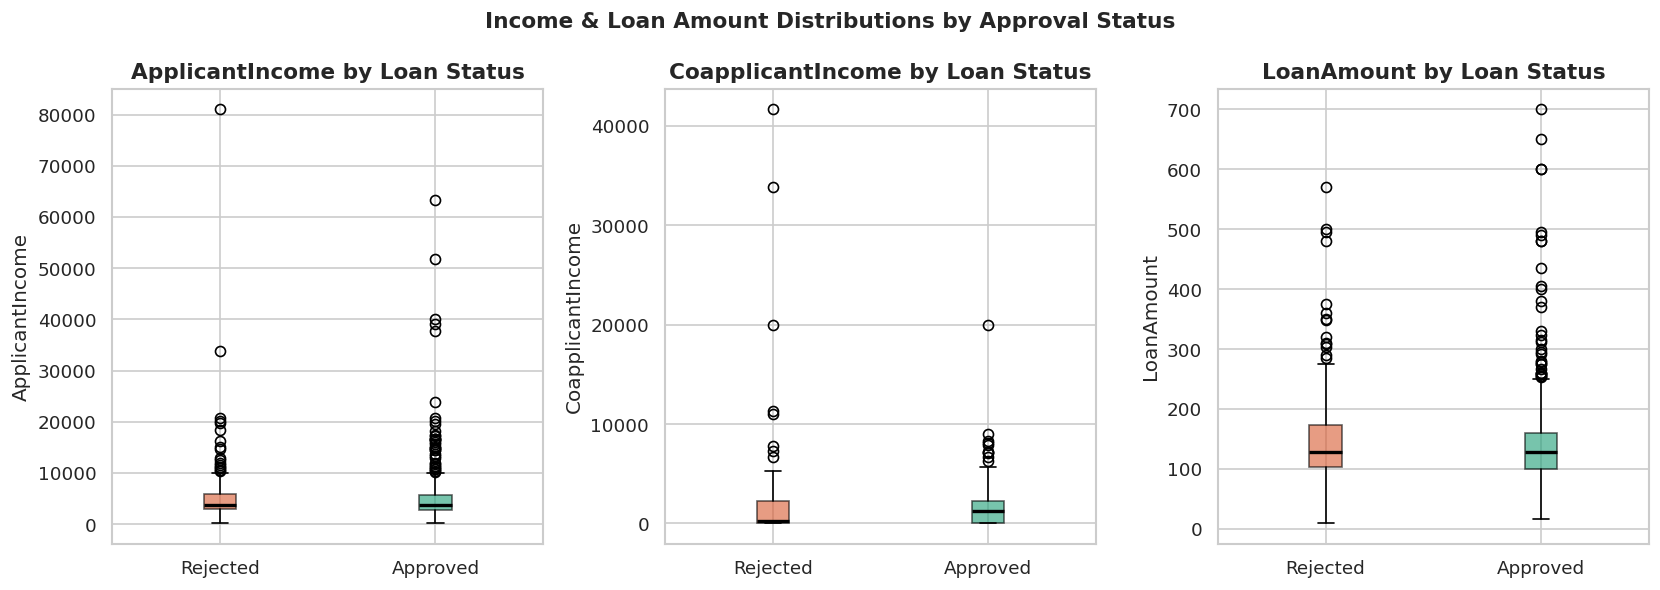

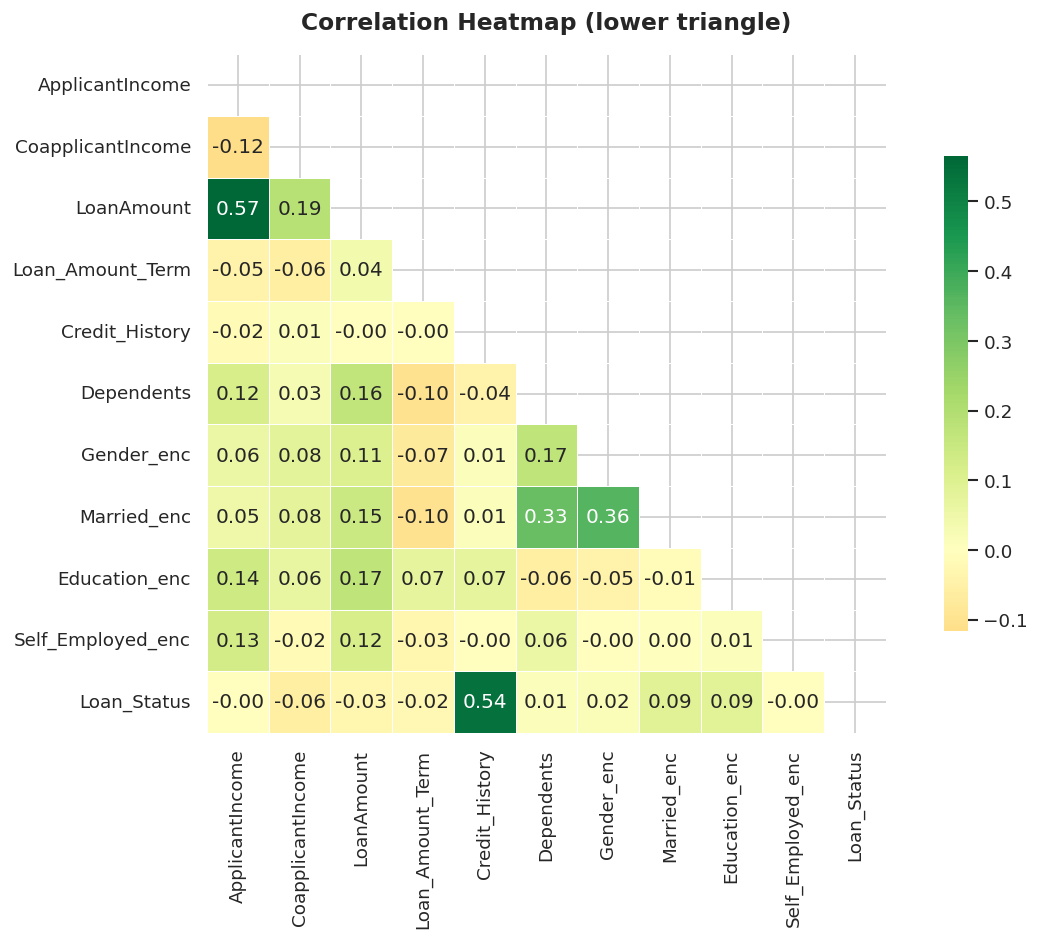

In [5]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

STATUS_LABELS = {0: "Rejected", 1: "Approved"}
STATUS_COLORS = ["#D85A30", "#1D9E75"]

def plot_target(df, target="Loan_Status"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    counts = df[target].value_counts()
    axes[0].bar(counts.index, counts.values, color=["#1D9E75", "#D85A30"], edgecolor="white", width=0.5)
    axes[0].set_title("Loan Status — Count")
    axes[0].set_ylabel("Count")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")
    axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
                colors=["#1D9E75", "#D85A30"], startangle=90,
                wedgeprops={"edgecolor": "white", "linewidth": 2})
    axes[1].set_title("Loan Status — Proportion")
    plt.suptitle("Class Balance Check", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

def plot_num_distributions(df):
    num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
    fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))
    for i, col in enumerate(num_cols):
        data = df[col].dropna().astype(float)
        axes[i, 0].hist(data, bins=40, color="#378ADD", edgecolor="white", alpha=0.8)
        axes[i, 0].set_title(f"{col} — Distribution")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Frequency")
        axes[i, 0].text(0.97, 0.95, f"Skew: {data.skew():.2f}",
                        transform=axes[i, 0].transAxes, ha="right", va="top",
                        fontsize=10, color="darkred",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                           boxprops=dict(facecolor="#378ADD", alpha=0.6),
                           medianprops=dict(color="red", linewidth=2))
        axes[i, 1].set_title(f"{col} — Boxplot (outlier check)")
        axes[i, 1].set_xlabel(col)
    plt.suptitle("Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

def plot_log_transform(df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for i, col in enumerate(["ApplicantIncome", "CoapplicantIncome"]):
        data = df[col].dropna().astype(float)
        log_data = np.log1p(data)
        axes[i, 0].hist(data, bins=50, color="#D85A30", edgecolor="white", alpha=0.8)
        axes[i, 0].set_title(f"{col} — Raw (skew: {data.skew():.2f})")
        axes[i, 1].hist(log_data, bins=50, color="#1D9E75", edgecolor="white", alpha=0.8)
        axes[i, 1].set_title(f"log1p({col}) — Transformed (skew: {log_data.skew():.2f})")
    plt.suptitle("Why Log Transform is Needed", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_cat_distributions(df):
    cat_cols_plot = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
    df = df.copy()
    for col in cat_cols_plot:
        if col in df.columns:
            df[col] = df[col].astype(str)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    colors = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517", "#7F77DD", "#888780"]
    for i, col in enumerate(cat_cols_plot):
        counts = df[col].value_counts(dropna=False)
        axes[i].bar([str(x) for x in counts.index], counts.values,
                    color=colors[i], edgecolor="white", alpha=0.85)
        axes[i].set_title(col)
        axes[i].set_ylabel("Count")
        for j, v in enumerate(counts.values):
            axes[i].text(j, v + 2, str(v), ha="center", fontsize=9, fontweight="bold")
        axes[i].tick_params(axis="x", rotation=15)
    plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_cat_vs_target(df, target="Loan_Status"):
    cat_cols_plot = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
    df = df.copy()
    df[target] = df[target].astype(int)
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols_plot):
        ct = pd.crosstab(df[col], df[target], normalize="index") * 100
        ct.plot(kind="bar", ax=axes[i], color=["#D85A30", "#1D9E75"],
                edgecolor="white", width=0.6)
        axes[i].set_title(f"{col} vs Loan_Status")
        axes[i].set_ylabel("Approval Rate (%)")
        axes[i].set_xlabel("")
        axes[i].tick_params(axis="x", rotation=15)
        axes[i].legend(title="Status", labels=["Rejected", "Approved"])
        axes[i].set_ylim(0, 110)
        for container in axes[i].containers:
            axes[i].bar_label(container, fmt="%.1f%%", fontsize=8)
    plt.suptitle("Categorical Features vs Loan Status (Approval Rate %)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_boxplots_vs_target(df, target="Loan_Status"):
    num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
    df = df.copy()
    df[target] = df[target].astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for i, col in enumerate(num_cols):
        groups = [df[df[target] == s][col].dropna().astype(float) for s in [0, 1]]
        bp = axes[i].boxplot(groups, patch_artist=True, labels=["Rejected", "Approved"],
                             medianprops=dict(color="black", linewidth=2))
        bp["boxes"][0].set_facecolor("#D85A30")
        bp["boxes"][0].set_alpha(0.6)
        bp["boxes"][1].set_facecolor("#1D9E75")
        bp["boxes"][1].set_alpha(0.6)
        axes[i].set_title(f"{col} by Loan Status")
        axes[i].set_ylabel(col)
    plt.suptitle("Income & Loan Amount Distributions by Approval Status", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, target="Loan_Status"):
    temp = df.copy()
    temp[target] = temp[target].astype(int)
    temp["Gender_enc"] = (temp["Gender"] == "Male").astype(float)
    temp["Married_enc"] = (temp["Married"] == "Yes").astype(float)
    temp["Education_enc"] = (temp["Education"] == "Graduate").astype(float)
    temp["Self_Employed_enc"] = (temp["Self_Employed"] == "Yes").astype(float)
    cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
            "Loan_Amount_Term", "Credit_History", "Dependents",
            "Gender_enc", "Married_enc", "Education_enc", "Self_Employed_enc", target]
    corr = temp[cols].astype(float).corr()
    plt.figure(figsize=(11, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.7})
    plt.title("Correlation Heatmap (lower triangle)", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

def run_full_eda(df):
    plot_target(df)
    plot_num_distributions(df)
    plot_log_transform(df)
    plot_cat_distributions(df)
    plot_cat_vs_target(df)
    plot_boxplots_vs_target(df)
    plot_correlation_heatmap(df)

run_full_eda(df_raw)

## Feature Engineering & Transformation

Two datasets are prepared for parallel experiments:

### `df_base` — Baseline (label-encoded only)
Raw features with `LabelEncoder` applied to all `object` columns. Serves as the control benchmark.

### `df_eng` — Engineered Dataset
New financial features are derived to capture repayment capacity:

| Feature | Formula | Meaning |
|---|---|---|
| `TotalIncome` | $A + C$ | Combined household income |
| `DebtToIncome` | $\frac{\text{LoanAmount} \times 1000}{\text{TotalIncome}}$ | Debt burden relative to earnings |
| `EMI` | $\frac{\text{LoanAmount}}{\text{Loan\_Amount\_Term}}$ | Estimated monthly instalment |
| `BalanceIncome` | $\text{TotalIncome} - \text{EMI} \times 1000$ | Disposable income after repayment |
| `ApplicantIncome_log` | $\log(1 + \text{ApplicantIncome})$ | Skew-corrected income |
| `TotalIncome_log` | $\log(\text{TotalIncome})$ | Skew-corrected combined income |
| `LoanAmount_log` | $\log(\text{LoanAmount})$ | Skew-corrected loan size |

Raw income and loan-amount columns are dropped after transformation to avoid redundancy. All remaining categoricals are label-encoded.

In [6]:
df_base = df_raw.copy()
le_base = {}
for col in df_base.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_base[col] = le.fit_transform(df_base[col])
    le_base[col] = le

df_eng = df_raw.copy()
df_eng['TotalIncome'] = df_eng['ApplicantIncome'] + df_eng['CoapplicantIncome']
df_eng['DebtToIncome'] = (df_eng['LoanAmount'] * 1000) / df_eng['TotalIncome']
df_eng['EMI'] = df_eng['LoanAmount'] / df_eng['Loan_Amount_Term']
df_eng['BalanceIncome'] = df_eng['TotalIncome'] - (df_eng['EMI'] * 1000)
df_eng['ApplicantIncome_log'] = np.log1p(df_eng['ApplicantIncome'])
df_eng['TotalIncome_log'] = np.log(df_eng['TotalIncome'])
df_eng['LoanAmount_log'] = np.log(df_eng['LoanAmount'])
df_eng.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'], axis=1, inplace=True)

le_eng = {}
for col in df_eng.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_eng[col] = le.fit_transform(df_eng[col])
    le_eng[col] = le

## Stratified K-Fold Cross-Validation Framework

### Why Stratified K-Fold?
With an imbalanced target, random splitting can place most minority-class samples in one fold. Stratification preserves the approval/rejection ratio across every fold:
$$\frac{|\text{Positive}|}{|\text{Negative}|} = \text{constant in each fold}$$

### Models evaluated (5 folds, `random_state=49`):

| Model | Key config |
|---|---|
| `LogisticRegression` | `class_weight='balanced'`, `max_iter=5000` |
| `XGBClassifier` | `max_depth=3`, `learning_rate=0.01`, `n_estimators=200` |
| `RandomForestClassifier` | `n_estimators=200`, `max_depth=5`, `class_weight='balanced'` |

### Metrics reported per model:

| Metric | Formula |
|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ |
| Precision | $\frac{TP}{TP+FP}$ |
| Recall | $\frac{TP}{TP+FN}$ |
| F1 | $2 \cdot \frac{P \cdot R}{P+R}$ |
| ROC-AUC | Area under the ROC curve; 0.5 = random, 1.0 = perfect |

Results are returned as a dict for downstream comparison.

In [7]:
def evaluate_k_fold(X, Y, dataset):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=49)
    models = {
        'Logistic Regression': LogisticRegression(max_iter=5000, random_state=49, class_weight='balanced'),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=3, learning_rate=0.01, n_estimators=200, random_state=49),
        'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=49, class_weight='balanced')
    }

    scoring_metrics = ['accuracy', 'precision', 'recall', 'roc_auc', 'f1']
    results= {}
    
    print(f"\n" + "="*85)
    print(f"EVALUATING {dataset.upper()} DATA".center(85))
    print("="*85)
    print(f"{'MODEL NAME':<20} | {'ACCURACY':<10} | {'PRECISION':<10} | {'RECALL':<10} | {'ROC-AUC':<10} | {'F1 SCORE'}")
    print("-" * 85)
    
    for name, model in models.items():
        cv_results = cross_validate(model, X, Y, cv=skf, scoring=scoring_metrics)

        acc = cv_results['test_accuracy'].mean()
        prec = cv_results['test_precision'].mean()
        rec = cv_results['test_recall'].mean()
        roc_auc = cv_results['test_roc_auc'].mean()
        f1 = cv_results['test_f1'].mean()
        
        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'roc_auc': roc_auc,
            'f1': f1
        }
        
        print(f"{name:<20} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {roc_auc:<10.4f} | {f1:.4f}")

        # We are fitting on full dataset after CV evaluation.
        # These final-fitted models are used for the downstream VotingClassifier, not for any further evaluation — so no leakage concern.
        model.fit(X, Y)
    return results, models

## Running Cross-Validation on Both Datasets

`evaluate_k_fold` is called on **baseline** and **engineered** feature sets separately, allowing a direct comparison of the impact of feature engineering.

After individual model evaluation, a **Soft Voting Classifier** is assembled from the three trained models:

$$P(y = c) = \frac{1}{3}\sum_{i=1}^{3} P_i(y = c)$$

Each model votes with its predicted probability; the class with the highest average probability wins. This reduces variance compared to any single classifier.

In [8]:
X_base, Y_base = df_base.drop('Loan_Status', axis=1), df_base['Loan_Status']
base_results, _ = evaluate_k_fold(X_base, Y_base, "Baseline")

X_eng, Y_eng = df_eng.drop('Loan_Status', axis=1), df_eng['Loan_Status']
eng_results, trained_models = evaluate_k_fold(X_eng, Y_eng, "Engineered")

voting_clf = VotingClassifier(
    estimators=[
        ('lr', trained_models['Logistic Regression']),
        ('xgb', trained_models['XGBoost']),
        ('rf', trained_models['Random Forest'])
    ],
    voting='soft'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=49)
scoring_metrics = ['accuracy', 'precision', 'recall', 'roc_auc', 'f1']
ensemble_cv_results = cross_validate(voting_clf, X_eng, Y_eng, cv=skf, scoring=scoring_metrics)

ens_acc = ensemble_cv_results['test_accuracy'].mean()
ens_prec = ensemble_cv_results['test_precision'].mean()
ens_rec = ensemble_cv_results['test_recall'].mean()
ens_roc_auc = ensemble_cv_results['test_roc_auc'].mean()
ens_f1 = ensemble_cv_results['test_f1'].mean()

print(f"\n" + "="*85)
print(f"EVALUATING FINAL ENSEMBLE (SOFT VOTING)".center(85))
print("="*85)
print(f"{'MODEL NAME':<20} | {'ACCURACY':<10} | {'PRECISION':<10} | {'RECALL':<10} | {'ROC-AUC':<10} | {'F1 SCORE'}")
print("-" * 85)
print(f"{'Soft Voting Ensemble':<20} | {ens_acc:<10.4f} | {ens_prec:<10.4f} | {ens_rec:<10.4f} | {ens_roc_auc:<10.4f} | {ens_f1:.4f}")
print("="*85 + "\n")


                               EVALUATING BASELINE DATA                              
MODEL NAME           | ACCURACY   | PRECISION  | RECALL     | ROC-AUC    | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression  | 0.7703     | 0.7979     | 0.8934     | 0.7198     | 0.8423
XGBoost              | 0.8094     | 0.7909     | 0.9834     | 0.7321     | 0.8766
Random Forest        | 0.7964     | 0.7912     | 0.9573     | 0.7379     | 0.8661

                              EVALUATING ENGINEERED DATA                             
MODEL NAME           | ACCURACY   | PRECISION  | RECALL     | ROC-AUC    | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression  | 0.7687     | 0.7972     | 0.8911     | 0.7196     | 0.8409
XGBoost              | 0.8110     | 0.7958     | 0.9763     | 0.7573     | 0.8768
Random Forest        | 0.8029     | 0.8086     | 0.9360     | 0.7576     | 0

## Experiment Summary

Results from all models on both datasets are compiled into a comparison DataFrame. Metrics printed side-by-side:

- **Baseline Acc / ROC-AUC / F1** — raw features + label encoding only  
- **Engineered Acc / ROC-AUC / F1** — with financial ratio features and log-transforms  
- **Soft Voting Ensemble** — combined prediction on engineered features

This table guides the decision of which dataset and which model configuration to carry forward into hyperparameter tuning.

In [9]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Baseline Acc': [base_results['Logistic Regression']['accuracy'], base_results['XGBoost']['accuracy'], base_results['Random Forest']['accuracy']],
    'Engineered Acc': [eng_results['Logistic Regression']['accuracy'], eng_results['XGBoost']['accuracy'], eng_results['Random Forest']['accuracy']],
    'Baseline ROC-AUC': [base_results['Logistic Regression']['roc_auc'], base_results['XGBoost']['roc_auc'], base_results['Random Forest']['roc_auc']],
    'Engineered ROC-AUC': [eng_results['Logistic Regression']['roc_auc'], eng_results['XGBoost']['roc_auc'], eng_results['Random Forest']['roc_auc']],
    'Baseline F1': [base_results['Logistic Regression']['f1'], base_results['XGBoost']['f1'], base_results['Random Forest']['f1']],
    'Engineered F1': [eng_results['Logistic Regression']['f1'], eng_results['XGBoost']['f1'], eng_results['Random Forest']['f1']]
})

print("\n" + "="*85)
print("FINAL EXPERIMENT SUMMARY".center(85))
print("="*85)
print(f"{'MODEL NAME':<20}| {'BASE ACC':<11}| {'ENG ACC':<10} | {'BASE AUC-ROC':<10} | {'ENG ROC-AUC'} | {'BASE F1':<10} | {'ENG F1'}")
print("-" * 85)

for index, row in comparison_df.iterrows():
    print(f"{row['Model']:<19} | {row['Baseline Acc']:<10.4f} | {row['Engineered Acc']:<10.4f} | {row['Baseline ROC-AUC']:<12.4f} | {row['Engineered ROC-AUC']:<11.4f} | {row['Baseline F1']:<10.4f} | {row['Engineered F1']:.4f}")

print("-" * 85)
print(f"SOFT VOTING ENSEMBLE ACCURACY SCORE : {ens_acc:.4f}")
print(f"SOFT VOTING ENSEMBLE ROC-AUC SCORE : {ens_roc_auc:.4f}")
print(f"SOFT VOTING ENSEMBLE F1 SCORE : {ens_f1:.4f}")
print("=" * 39 + "\n")


                               FINAL EXPERIMENT SUMMARY                              
MODEL NAME          | BASE ACC   | ENG ACC    | BASE AUC-ROC | ENG ROC-AUC | BASE F1    | ENG F1
-------------------------------------------------------------------------------------
Logistic Regression | 0.7703     | 0.7687     | 0.7198       | 0.7196      | 0.8423     | 0.8409
XGBoost             | 0.8094     | 0.8110     | 0.7321       | 0.7573      | 0.8766     | 0.8768
Random Forest       | 0.7964     | 0.8029     | 0.7379       | 0.7576      | 0.8661     | 0.8673
-------------------------------------------------------------------------------------
SOFT VOTING ENSEMBLE ACCURACY SCORE : 0.8143
SOFT VOTING ENSEMBLE ROC-AUC SCORE : 0.7452
SOFT VOTING ENSEMBLE F1 SCORE : 0.8778



## Post-Tuning Evaluation + Feature Importance

After hyperparameter tuning, this function:
1. Re-runs 5-fold stratified cross-validation on the tuned model and prints all five metrics.
2. Fits the model on the full dataset.
3. Extracts and plots **feature importance**:

| Model type | Importance measure |
|---|---|
| Tree-based (XGBoost, Random Forest) | `model.feature_importances_` — mean decrease in impurity |
| Linear (Logistic Regression) | `|model.coef_[0]|` — absolute coefficient weights |

The bar chart ranks features from most to least influential, revealing which engineered features (e.g. `Credit_History`, `BalanceIncome`) drive predictions most.

In [10]:
def evaluate_model_hypertune(X, Y, dataset, model, model_name):
    print("\n" + "="*60)
    print(f"EVALUATING FINAL TUNED {model_name.upper()} {dataset.upper()} DATA".center(60))
    print("="*60)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=49)
    scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'f1']
    cv_results = cross_validate(model, X, Y, cv=skf, scoring=scoring)

    print(f"Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
    print(f"Precision : {cv_results['test_precision'].mean():.4f}")
    print(f"Recall    : {cv_results['test_recall'].mean():.4f}")
    print(f"ROC-AUC   : {cv_results['test_roc_auc'].mean():.4f}")
    print(f"F1-Score  : {cv_results['test_f1'].mean():.4f}")
    print("="*60 + "\n")

    model.fit(X, Y)

    if hasattr(model, 'feature_importances_'):
        # For Tree-based models (XGBoost, Random Forest)
        importances = model.feature_importances_
        x_label = 'Relative Importance'
    elif hasattr(model, 'coef_'):
        # For Linear models (Logistic Regression)
        # We are using absolute value because coefficients can be negative!
        importances = np.abs(model.coef_[0])
        x_label = 'Absolute Coefficient Weight'
    else:
        print(f"Warning: {model_name} does not support feature importance extraction.")
        return model
    indices = np.argsort(importances)[::-1]
    features = X.columns
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
    plt.title(f'{model_name} Feature Importance (What drives Loan Approvals?)', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return model

## Hyperparameter Tuning with Randomized Search

`RandomizedSearchCV` samples `n_iter=100` random combinations from the supplied parameter distributions and selects the combination that maximises `roc_auc` under stratified 5-fold CV.

**Why Randomized over Grid Search?**  
Grid search tests every combination — $O(|\text{grid}|)$ fits. Randomized search samples from continuous distributions, making it orders-of-magnitude faster for large search spaces while still finding near-optimal parameters.

The function returns `random_search.best_estimator_` — the refitted model with the best found hyperparameters.

In [11]:
def tune_hyperparameters(model, param_grid, X, Y, model_name="Model", scoring_metric='roc_auc', cv_splits=5):
    print("\n" + "="*85)
    print(f"HYPERPARAMETER TUNING: {model_name.upper()}".center(85))
    print("="*85)
    print(f"Optimizing for : {scoring_metric.upper()}")
    print(f"CV Folds       : {cv_splits}")
    print("-" * 85)
    
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=49)
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=100,
        scoring=scoring_metric,
        cv=skf,
        random_state=49,
        n_jobs=-1,
        verbose=1
    )
    
    print(f"Executing randomized search...")
    random_search.fit(X, Y)
    
    print("\n" + "-" * 85)
    print(f"TUNING COMPLETE FOR {model_name.upper()} ({scoring_metric.upper()})".center(85))
    print("-" * 85)
    print(f"Best Score       : {random_search.best_score_:.4f}")
    print(f"Best Parameters  :")
    
    for key, value in random_search.best_params_.items():
        print(f"   - {key:<20}: {value}")
    print("="*85 + "\n")
    
    return random_search.best_estimator_

## Defining Parameter Grids & Running Tuning

Separate grids are defined for each algorithm:

**Logistic Regression**
- `C` — inverse regularisation strength; smaller → stronger L1/L2 penalty → sparser weights
- `penalty` — `l1` zeros out irrelevant features; `l2` shrinks all weights
- `solver='liblinear'` — efficient for small datasets, supports both penalties

**XGBoost**
- `max_depth` — controls tree complexity; deeper → more expressive but higher overfit risk
- `learning_rate (η)` — step size: $F_m(x) = F_{m-1}(x) + \eta h_m(x)$
- `subsample` / `colsample_bytree` — row/column subsampling for variance reduction
- `gamma` — minimum loss reduction required to make a split
- `reg_lambda` — L2 regularisation on leaf weights

**Random Forest**
- `n_estimators`, `max_depth`, `min_samples_split/leaf` — tree structure controls
- `max_features ∈ {sqrt, log2}` — number of features considered at each split
- `max_samples` — fraction of training set used per tree (bagging ratio)

Each model is tuned on both baseline and engineered datasets, yielding six tuned estimators total.


                HYPERPARAMETER TUNING: LOGISTIC REGRESSION : BASELINE                
Optimizing for : ROC_AUC
CV Folds       : 5
-------------------------------------------------------------------------------------
Executing randomized search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

-------------------------------------------------------------------------------------
             TUNING COMPLETE FOR LOGISTIC REGRESSION : BASELINE (ROC_AUC)            
-------------------------------------------------------------------------------------
Best Score       : 0.7185
Best Parameters  :
   - solver              : liblinear
   - penalty             : l1
   - C                   : 10


               HYPERPARAMETER TUNING: LOGISTIC REGRESSION : ENGINEERED               
Optimizing for : ROC_AUC
CV Folds       : 5
-------------------------------------------------------------------------------------
Executing randomized search...
Fitting 5 folds for each of 12 candidates

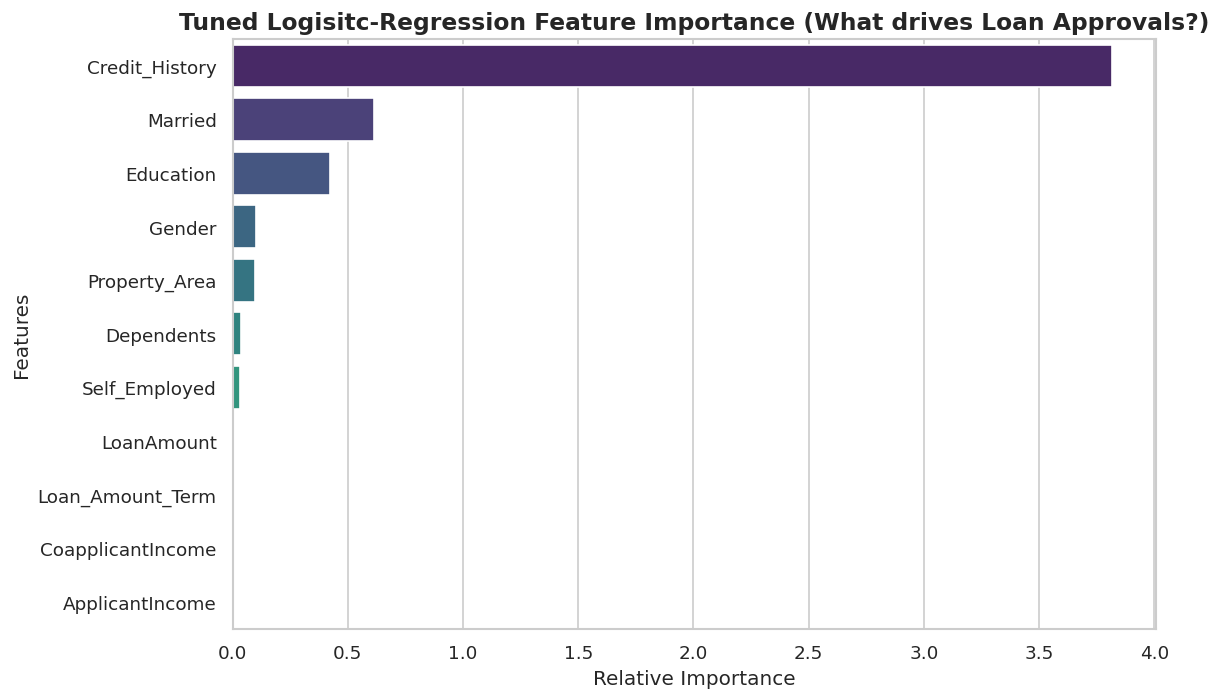


EVALUATING FINAL TUNED TUNED LOGISTIC-REGRESSION ENGINEERED DATA
Accuracy  : 0.7850
Precision : 0.8002
Recall    : 0.9172
ROC-AUC   : 0.7269
F1-Score  : 0.8542



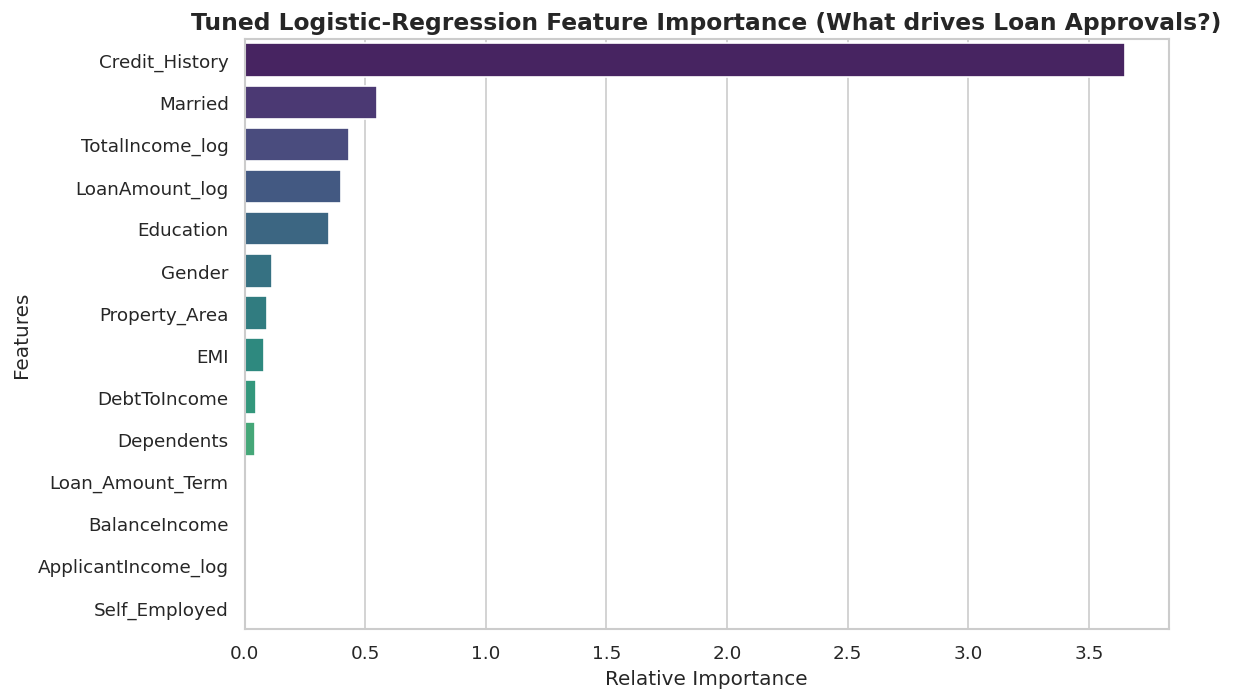


     EVALUATING FINAL TUNED TUNED XGBOOST BASELINE DATA     
Accuracy  : 0.7785
Precision : 0.7921
Recall    : 0.9195
ROC-AUC   : 0.7682
F1-Score  : 0.8510



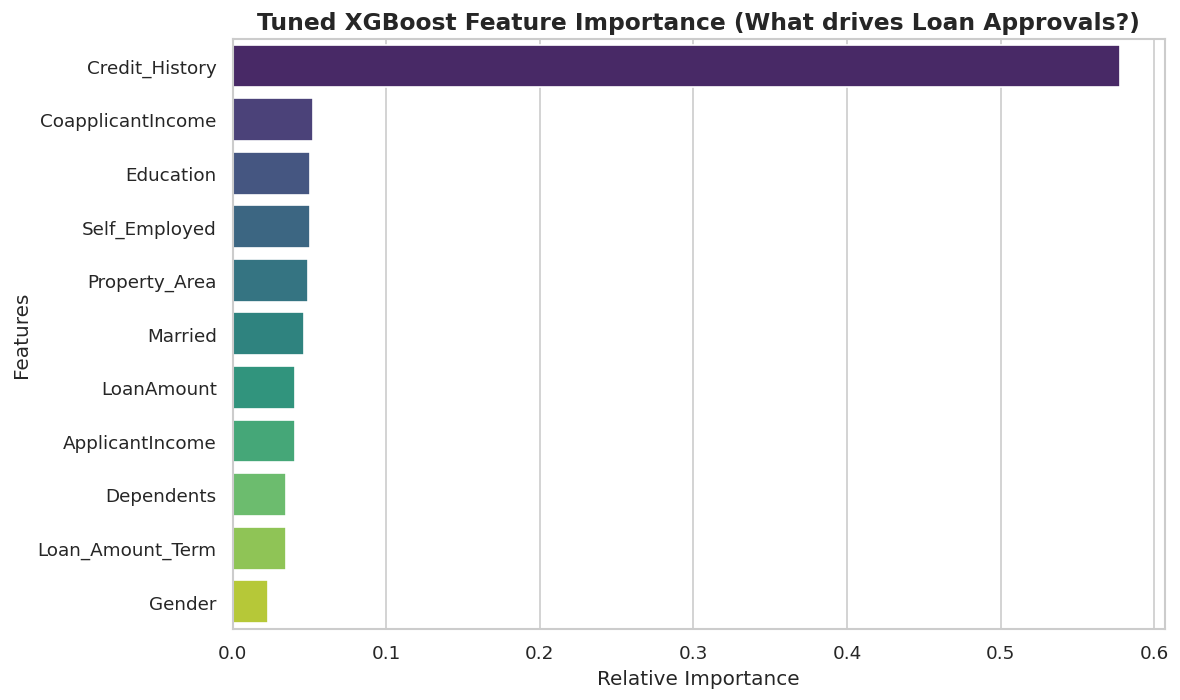


    EVALUATING FINAL TUNED TUNED XGBOOST ENGINEERED DATA    
Accuracy  : 0.8046
Precision : 0.8037
Recall    : 0.9480
ROC-AUC   : 0.7720
F1-Score  : 0.8697



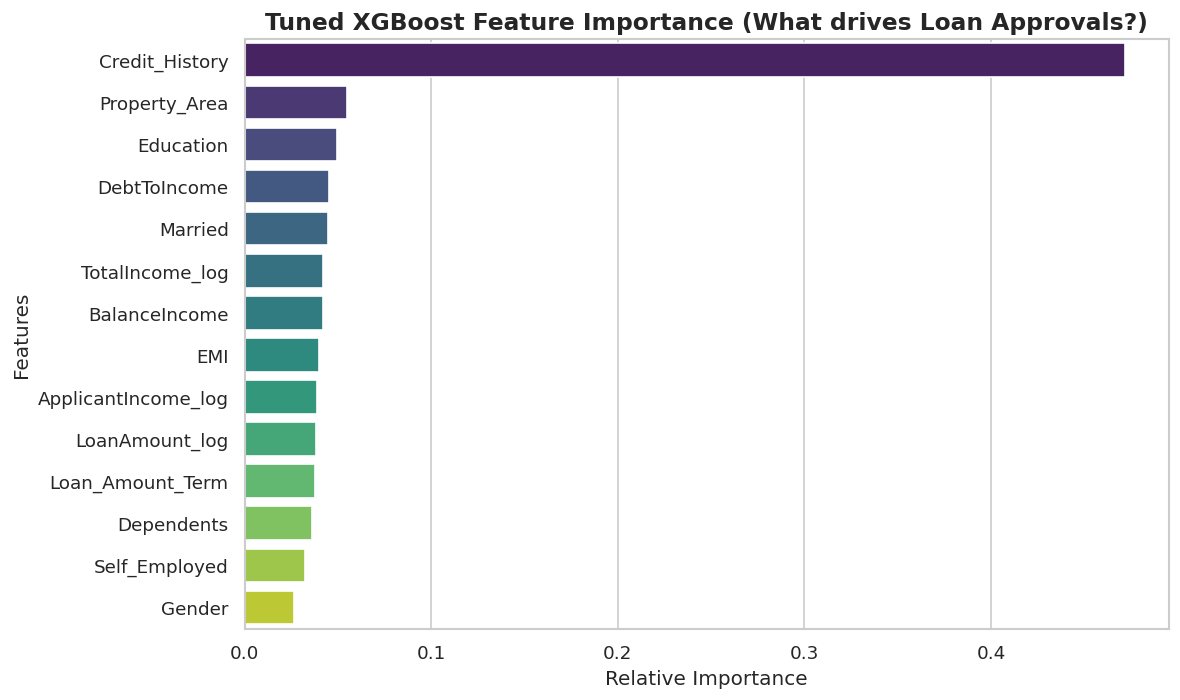


  EVALUATING FINAL TUNED TUNED RANDOM-FOREST BASELINE DATA  
Accuracy  : 0.7948
Precision : 0.7930
Recall    : 0.9503
ROC-AUC   : 0.7660
F1-Score  : 0.8643



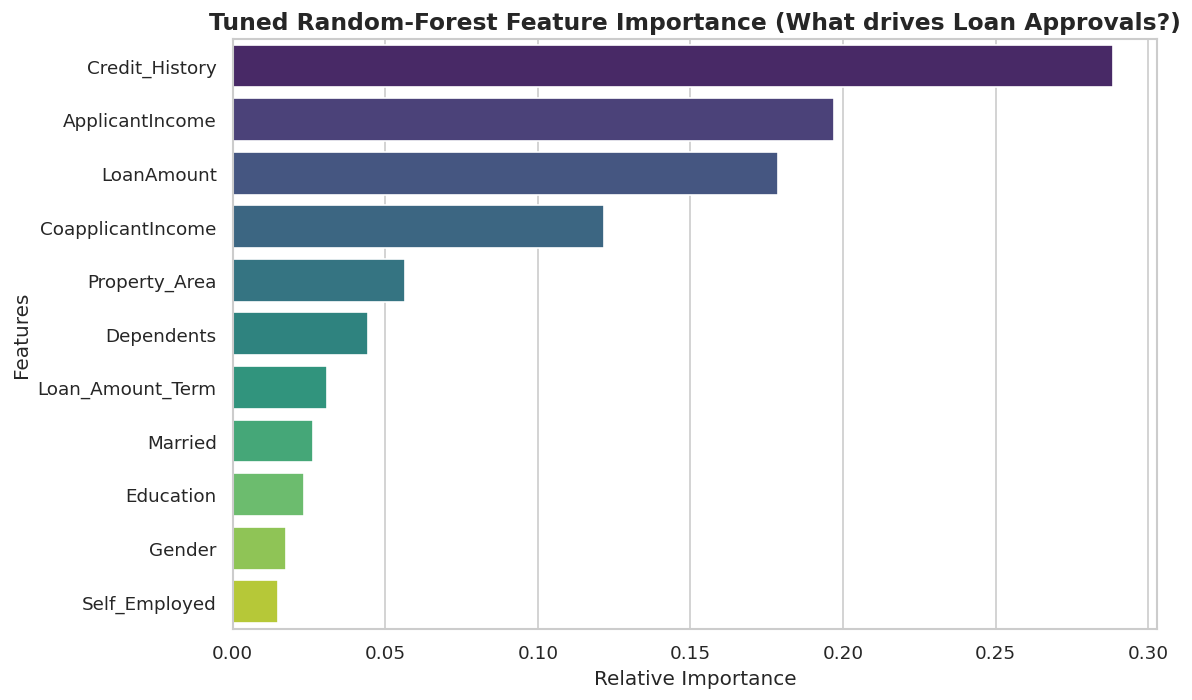


 EVALUATING FINAL TUNED TUNED RANDOM-FOREST ENGINEERED DATA 
Accuracy  : 0.8013
Precision : 0.8122
Recall    : 0.9265
ROC-AUC   : 0.7723
F1-Score  : 0.8651



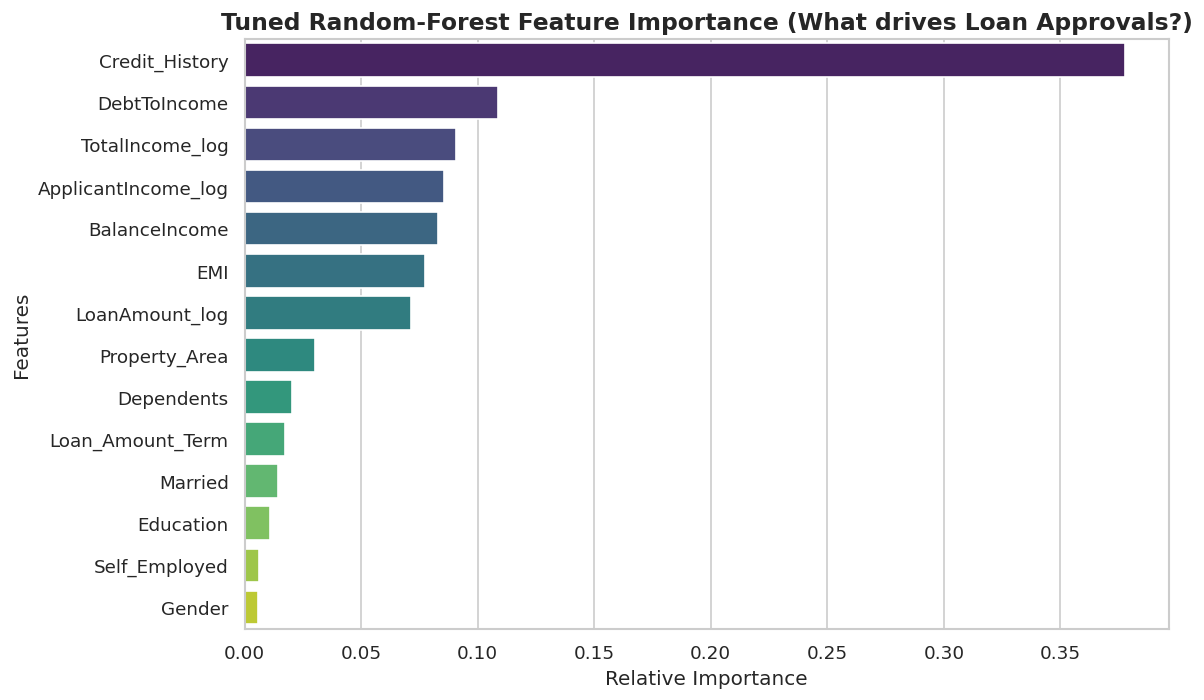

In [12]:
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],          # Regularization strength (smaller values = stronger penalty)
    'penalty': ['l1', 'l2'],                      # L1 can mathematically delete useless features. L2 shrinks them.
    'solver': ['liblinear']                       # 'liblinear' is highly optimized for small datasets and supports L1/L2
}
xgb_param_grid = {
    'max_depth': randint(3, 8),                   # How deep the decision trees can grow
    'learning_rate': [0.01, 0.05, 0.1],           # Step size optimization
    'n_estimators': [100, 200, 300],              # Total number of sequential trees
    'subsample': [0.8, 1.0],                      # % of data used per tree (prevents overfitting)
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],     # % of features used per tree (prevents multicollinearity)
    'gamma': [0, 0.5, 1.0],                       # Minimum loss reduction to make a split
    'reg_lambda': [1, 5, 10]                      # L2 penalty to stop over-reliance on one feature
}
rf_param_grid = {
    'n_estimators': randint(100, 500),            # Total number of independent trees in the forest
    'max_depth': randint(3, 15),                  # How deep each individual tree can grow
    'min_samples_split': randint(2, 15),          # Min samples required to split an internal node (higher stops overfitting)
    'min_samples_leaf': randint(1, 10),           # Min samples required to be at a leaf node (smooths predictions)
    'max_features': ['sqrt', 'log2'],             # Number of features to consider when looking for the best split
    'max_samples': uniform(0.6, 0.4)              # % of data used to train each tree (bootstrap sample size)
}
X_final_base = df_base.drop('Loan_Status', axis=1)
Y_final_base = df_base['Loan_Status']

X_final_eng = df_eng.drop('Loan_Status', axis=1)
Y_final_eng = df_eng['Loan_Status']

raw_lr = LogisticRegression(max_iter=5000, random_state=49, class_weight='balanced')
raw_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=49)
raw_rf = RandomForestClassifier(random_state=49, class_weight='balanced')

best_lr_model_base = tune_hyperparameters(model=raw_lr, param_grid=lr_param_grid, X=X_final_base, Y=Y_final_base, model_name="Logistic Regression : Baseline",scoring_metric='roc_auc')
best_lr_model_eng = tune_hyperparameters(model=raw_lr, param_grid=lr_param_grid, X=X_final_eng, Y=Y_final_eng, model_name="Logistic Regression : Engineered",scoring_metric='roc_auc')

best_xgb_model_base = tune_hyperparameters(model=raw_xgb, param_grid=xgb_param_grid, X=X_final_base, Y=Y_final_base, model_name="XGBoost : Baseline",scoring_metric='roc_auc')
best_xgb_model_eng = tune_hyperparameters(model=raw_xgb, param_grid=xgb_param_grid, X=X_final_eng, Y=Y_final_eng, model_name="XGBoost : Engineered",scoring_metric='roc_auc')

best_rf_model_base = tune_hyperparameters(model=raw_rf, param_grid=rf_param_grid, X=X_final_base, Y=Y_final_base, model_name="Random Forest : Baseline",scoring_metric='roc_auc')
best_rf_model_eng = tune_hyperparameters(model=raw_rf, param_grid=rf_param_grid, X=X_final_eng, Y=Y_final_eng, model_name="Random Forest : Engineered",scoring_metric='roc_auc')

lr_base = evaluate_model_hypertune(X_final_base, Y_final_base, 'Baseline', model=best_lr_model_base, model_name='Tuned Logisitc-Regression')
lr_eng = evaluate_model_hypertune(X_final_eng, Y_final_eng, 'Engineered', model=best_lr_model_eng, model_name='Tuned Logistic-Regression')

xgb_base = evaluate_model_hypertune(X_final_base, Y_final_base, 'Baseline', model=best_xgb_model_base, model_name='Tuned XGBoost')
xgb_eng = evaluate_model_hypertune(X_final_eng, Y_final_eng, 'Engineered', model=best_xgb_model_eng, model_name='Tuned XGBoost')

rf_base = evaluate_model_hypertune(X_final_base, Y_final_base, 'Baseline', model=best_rf_model_base, model_name='Tuned Random-Forest')
rf_eng = evaluate_model_hypertune(X_final_eng, Y_final_eng, 'Engineered', model=best_rf_model_eng, model_name='Tuned Random-Forest')

## Custom SMOTE — Synthetic Minority Over-Sampling

SMOTE addresses class imbalance by generating **synthetic** minority-class samples rather than simply duplicating existing ones.

### Algorithm
1. For each minority sample $x_i$, find its $k$ nearest neighbours in feature space using Euclidean distance:
$$d(x, y) = \sqrt{\sum_{j=1}^{n}(x_j - y_j)^2}$$
2. Pick a random neighbour $x_{nn}$ and generate a synthetic point along the connecting segment:
$$x_{syn} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

### Parameters
- `target_class=0` — over-samples the **rejected** (minority) class
- `oversample_ratio=0.8` — generates 80 % more minority samples
- `k_neighbors=5` — neighbourhood size for interpolation

Categorical columns (if any) are handled separately — the nearest neighbour's category values are copied directly (no interpolation on discrete variables).

In [13]:
def apply_smote(X_train, Y_train, cat_cols=[], target_class=0, k_neighbors=5, oversample_ratio=1.0, verbose=True):
    if not cat_cols:
        X_num = X_train
        X_cat = pd.DataFrame(index=X_train.index)
    else:    
        X_num = X_train.drop(columns=cat_cols)
        X_cat = X_train[cat_cols]

    X_num_min = X_num[Y_train == target_class]
    X_cat_min = X_cat[Y_train == target_class]

    if isinstance(X_num_min, pd.DataFrame):
        X_num_min = X_num_min.values

    n_min = len(X_num_min)
    n_synthetic = int(n_min * oversample_ratio)

    if verbose:
        print(f"Original minority instances: {n_min}")
        print(f"Generating {n_synthetic} synthetic instances...")

    nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X_num_min)
    distances, indices = nn.kneighbors(X_num_min)
    
    synthetic_num = []
    synthetic_cat = []

    for _ in range(n_synthetic):
        i = np.random.randint(0, n_min)
        nn_index = indices[i, np.random.randint(1, k_neighbors + 1)]

        diff = X_num_min[nn_index] - X_num_min[i]
        gap = np.random.rand()
        synthetic_num.append(X_num_min[i] + gap * diff)
        if cat_cols:
            synthetic_cat.append(X_cat_min.iloc[i].values)
    
    synthetic_num = np.array(synthetic_num)
    if cat_cols:
        synthetic_cat = np.array(synthetic_cat)
        synthetic_full = np.hstack([synthetic_num, synthetic_cat])
    else:
        synthetic_full = synthetic_num
        
    X_original = X_train.values
    X_syn = np.vstack([X_original, synthetic_full])
    Y_syn = np.hstack([
        Y_train.values if isinstance(Y_train, pd.Series) else Y_train,
        np.full(n_synthetic, target_class)
    ])
    
    shuffle_idx = np.random.permutation(len(Y_syn))
    X_syn = X_syn[shuffle_idx]
    Y_syn = Y_syn[shuffle_idx]

    return X_syn, Y_syn

## Train / Test Split

```python
train_test_split(..., stratify=Y)
```

An 80/20 stratified split is applied so the class ratio in the held-out test set matches the full dataset. This prevents evaluation bias from accidentally over-representing either class in the test partition.

In [14]:
def split_data(X, Y, test_size=0.2, random_state=49):
    
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state, stratify=Y)
    return X_train, X_test, Y_train, Y_test

## Combined 5-Model Evaluation — With and Without SMOTE

All five models (Logistic Regression, Random Forest, XGBoost, Soft Voting, Stacking) are benchmarked in **two modes**:

**1. Standard CV** — `cross_validate` on the training set, no resampling.

**2. CV with SMOTE (manual fold-level)**  
SMOTE is applied *inside* each fold on the training partition only — never on the validation fold. This is the correct implementation to prevent data leakage:

For each fold:

    1. Apply SMOTE to X_fold_train → X_aug, Y_aug
    2. Fit model on X_aug, Y_aug
    3. Evaluate on untouched X_fold_test, Y_fold_test

Applying SMOTE before splitting would leak synthetic samples into the validation set and inflate metrics.

In [15]:
def evaluate_combined(X_train, Y_train, models, dataset, cat_cols=[]):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=49)
    scoring_metrics = ['accuracy', 'precision', 'recall', 'roc_auc', 'f1']

    print("\n" + "="*85)
    print(f"THE ULTIMATE 5-MODEL SHOWDOWN: {dataset.upper()} DATA".center(85))
    print("="*85)
    print(f"{'MODEL NAME':<20}| {'ACCURACY':<10}| {'PRECISION':<10}| {'RECALL':<10}| {'ROC-AUC':<10}| {'F1 SCORE'}")
    print("-" * 85)

    for name, model in models.items():
        cv_results = cross_validate(model, X_train, Y_train, cv=skf, scoring=scoring_metrics)
        acc = cv_results['test_accuracy'].mean()
        prec = cv_results['test_precision'].mean()
        rec = cv_results['test_recall'].mean()
        roc_auc = cv_results['test_roc_auc'].mean()
        f1 = cv_results['test_f1'].mean()
    
        clean_name = name.split('. ')[1]
        print(f"{clean_name:<20}| {acc:<10.4f}| {prec:<10.4f}| {rec:<10.4f}| {roc_auc:<10.4f}| {f1:.4f}")
    
    print("="*85 + "\n")
    print(f"THE ULTIMATE 5-MODEL SHOWDOWN: {dataset.upper()} DATA (WITH SMOTE)".center(85))
    print("="*85)
    print(f"{'MODEL NAME':<20}| {'ACCURACY':<10}| {'PRECISION':<10}| {'RECALL':<10}| {'ROC-AUC':<10}| {'F1 SCORE'}")
    print("-" * 85)

    smote_results = {name: {'acc': [], 'prec': [], 'rec': [], 'roc_auc': [], 'f1': []} for name in models.keys()}

    for train_idx, test_idx in skf.split(X_train, Y_train):
        X_fold_train, X_fold_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        Y_fold_train, Y_fold_test = Y_train.iloc[train_idx], Y_train.iloc[test_idx]
        
        X_fold_train_smote, Y_fold_train_smote = apply_smote(
            X_fold_train, Y_fold_train, target_class=0, oversample_ratio=0.8, verbose=False
        )
        X_fold_train_smote = pd.DataFrame(
        X_fold_train_smote,
        columns=X_train.columns
        ).astype({col: 'float64' if dtype == 'Int64' else dtype 
              for col, dtype in X_train.dtypes.items()})

        Y_fold_train_smote = pd.Series(Y_fold_train_smote)
        for name, model in models.items():
            model.fit(X_fold_train_smote, Y_fold_train_smote)
            y_pred = model.predict(X_fold_test)
            
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_fold_test)[:, 1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_fold_test)
            else:
                y_proba = y_pred
                
            smote_results[name]['acc'].append(accuracy_score(Y_fold_test, y_pred))
            smote_results[name]['prec'].append(precision_score(Y_fold_test, y_pred, zero_division=0))
            smote_results[name]['rec'].append(recall_score(Y_fold_test, y_pred, zero_division=0))
            smote_results[name]['roc_auc'].append(roc_auc_score(Y_fold_test, y_proba)) # <-- FIX
            smote_results[name]['f1'].append(f1_score(Y_fold_test, y_pred, zero_division=0))
    
    for name in models.keys():
        acc = np.mean(smote_results[name]['acc'])
        prec = np.mean(smote_results[name]['prec'])
        rec = np.mean(smote_results[name]['rec'])
        roc_auc = np.mean(smote_results[name]['roc_auc'])
        f1 = np.mean(smote_results[name]['f1'])
        
        clean_name = name.split('. ')[1] if '. ' in name else name
        print(f"{clean_name:<20}| {acc:<10.4f}| {prec:<10.4f}| {rec:<10.4f}| {roc_auc:<10.4f}| {f1:.4f}")
    
    print("="*85 + "\n")

## Final Evaluation on Held-Out Test Set

SMOTE is applied to the full training set (`oversample_ratio=0.8`), all five models are retrained, then evaluated on the isolated test partition that was never seen during training or tuning.

Outputs per model: Accuracy, Precision, Recall, ROC-AUC, F1.

**Confusion matrices** are plotted for all five models side-by-side, showing:

|  | Predicted Approved | Predicted Rejected |
|---|---|---|
| **Actual Approved** | TP | FN |
| **Actual Rejected** | FP | TN |

This reveals whether errors are skewed toward false approvals (costly to lender) or false rejections (costly to applicant).

In [16]:
def predict_and_compare(X_train, Y_train, X_test, Y_test, models, dataset, cat_cols=[]):  
    X_train_smote, Y_train_smote = apply_smote(X_train, Y_train, cat_cols=cat_cols, target_class=0, oversample_ratio=0.8, verbose=True)
    X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns).astype({col: 'float64' if str(dtype) == 'Int64' else dtype for col, dtype in X_train.dtypes.items()})

    for name, model in models.items():
        model.fit(X_train_smote, Y_train_smote)

    print(f"\n" + "="*85)
    print(f"DIAGNOSTIC PERFORMANCE ON UNSEEN {dataset.upper()} TEST DATA".center(85))
    print("="*85)
    print(f"{'MODEL NAME':<20} | {'ACCURACY':<10} | {'PRECISION':<10} | {'RECALL':<10} | {'ROC-AUC':<10} | {'F1 SCORE'}")
    print("-" * 85)

    preds_dict = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        preds_dict[name] = y_pred  # Cache for plotting step below
        
        # Safe extraction of probabilities for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            y_proba = y_pred

        acc = accuracy_score(Y_test, y_pred)
        prec = precision_score(Y_test, y_pred, zero_division=0)
        rec = recall_score(Y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(Y_test, y_proba)
        f1 = f1_score(Y_test, y_pred, zero_division=0)

        clean_name = name.split('. ')[1] if '. ' in name else name
        print(f"{clean_name:<20} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {roc_auc:<10.4f} | {f1:.4f}")

    print("="*85 + "\n")
    
    print(f"Generating Confusion matrices on isolated {dataset} Problem Dataset...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten() 
    cmaps = ['Reds', 'Greens', 'Blues', 'Purples', 'Oranges', 'Greys']

    for idx, (name, model) in enumerate(models.items()):
        disp = ConfusionMatrixDisplay(
            confusion_matrix(Y_test, model.predict(X_test)), 
            display_labels=['Rejected', 'Approved']
        )
        disp.plot(ax=axes[idx], cmap=cmaps[idx], colorbar=False)
        clean_name = name.split('. ')[1] if '. ' in name else name
        axes[idx].set_title(f"{clean_name} (Final Unseen Data)", fontweight='bold')

    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

## Inference Mode — Generating Submission CSV

When the test file has no `Loan_Status` column, this function runs in inference mode:

1. SMOTE is applied to the training data.
2. The **Stacking Classifier** (best generaliser) is trained on the augmented set.
3. Predictions are generated for the unlabelled problem set.
4. Labels are decoded back: $1 \rightarrow Y$, $0 \rightarrow N$.
5. Output is saved as `predicted_<dataset>.csv` with columns `Loan_ID`, `Loan_Status`.

In [17]:
def predict_and_submit(X_train, Y_train, X_problem, Y_problem, models, dataset, cat_cols=[], problem_ids=None):
    X_train_smote, Y_train_smote = apply_smote(X_train, Y_train, cat_cols=cat_cols, target_class=0, oversample_ratio=0.8, verbose=False)
    X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns).astype({col: 'float64' if str(dtype) == 'Int64' else dtype for col, dtype in X_train.dtypes.items()})

    model = models['5. Stacking Classifier']
    model.fit(X_train_smote, Y_train_smote)

    print(f"Generating predictions for {dataset}...")
    predictions = model.predict(X_problem)

    if problem_ids is None:
        problem_ids = [f"ID_{i}" for i in range(len(predictions))]
        
    submission = pd.DataFrame({'Loan_ID': problem_ids, 'Loan_Status': predictions})
    submission['Loan_Status'] = submission['Loan_Status'].map({1: 'Y', 0: 'N'})
    
    filename = f"predicted_{dataset.lower()}.csv"
    submission.to_csv(filename, index=False)
    print(f"Predictions saved to {filename}")

## Building the Ensemble Models

Two meta-ensemble methods are constructed from the three tuned base models:

**Soft Voting Classifier**  
Averages predicted class probabilities across all estimators:
$$\hat{y} = \arg\max_c \frac{1}{3}\sum_{i=1}^{3} P_i(y=c)$$

**Stacking Classifier**  
A two-level meta-learner:
1. Base models (LR, XGBoost, RF) generate out-of-fold predictions via internal 5-fold CV.
2. Those predictions become inputs to a `LogisticRegression` meta-model that learns how to combine them optimally.

Stacking can outperform voting when base models have complementary error patterns.

All five models (3 base + 2 ensemble) are returned in a numbered dict for consistent display ordering.

In [18]:
def build_ensemble(tuned_lr, tuned_xgb, tuned_rf):
    voting_soft = VotingClassifier(
        estimators=[('lr', tuned_lr), ('xgb', tuned_xgb), ('rf', tuned_rf)],
        voting='soft'
    )
    stacking = StackingClassifier(
        estimators=[('lr', tuned_lr), ('xgb', tuned_xgb), ('rf', tuned_rf)],
        final_estimator=LogisticRegression(class_weight='balanced'),
        cv=5
    )
    return {
        '1. Logistic Regression': tuned_lr,
        '2. Random Forest': tuned_rf,
        '3. XGBoost': tuned_xgb,
        '4. Soft Voting Ensemble': voting_soft,
        '5. Stacking Classifier': stacking
    }

## Full Pipeline Execution

This cell ties all components together:

1. **Build ensembles** from tuned base models for both baseline and engineered feature sets.
2. **Split data** (80/20 stratified) for both datasets.
3. **`evaluate_combined`** — 5-fold CV comparison (with and without SMOTE) on training data.
4. **`predict_and_compare`** — final metrics and confusion matrices on the held-out test set.

Running on both datasets side-by-side reveals whether the engineered features (DTI, EMI, BalanceIncome, log-transforms) materially improve generalisation over raw features.


                     THE ULTIMATE 5-MODEL SHOWDOWN: BASELINE DATA                    
MODEL NAME          | ACCURACY  | PRECISION | RECALL    | ROC-AUC   | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression | 0.7313    | 0.7841    | 0.8401    | 0.7116    | 0.8104
Random Forest       | 0.7821    | 0.7866    | 0.9378    | 0.7443    | 0.8551
XGBoost             | 0.7617    | 0.7849    | 0.8991    | 0.7577    | 0.8380
Soft Voting Ensemble| 0.7761    | 0.7921    | 0.9141    | 0.7566    | 0.8483
Stacking Classifier | 0.7273    | 0.7909    | 0.8193    | 0.7518    | 0.8039

              THE ULTIMATE 5-MODEL SHOWDOWN: BASELINE DATA (WITH SMOTE)              
MODEL NAME          | ACCURACY  | PRECISION | RECALL    | ROC-AUC   | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression | 0.7355    | 0.7852    | 0.8461    | 0.7128    | 0.8136
Random Forest       | 0.7760    | 

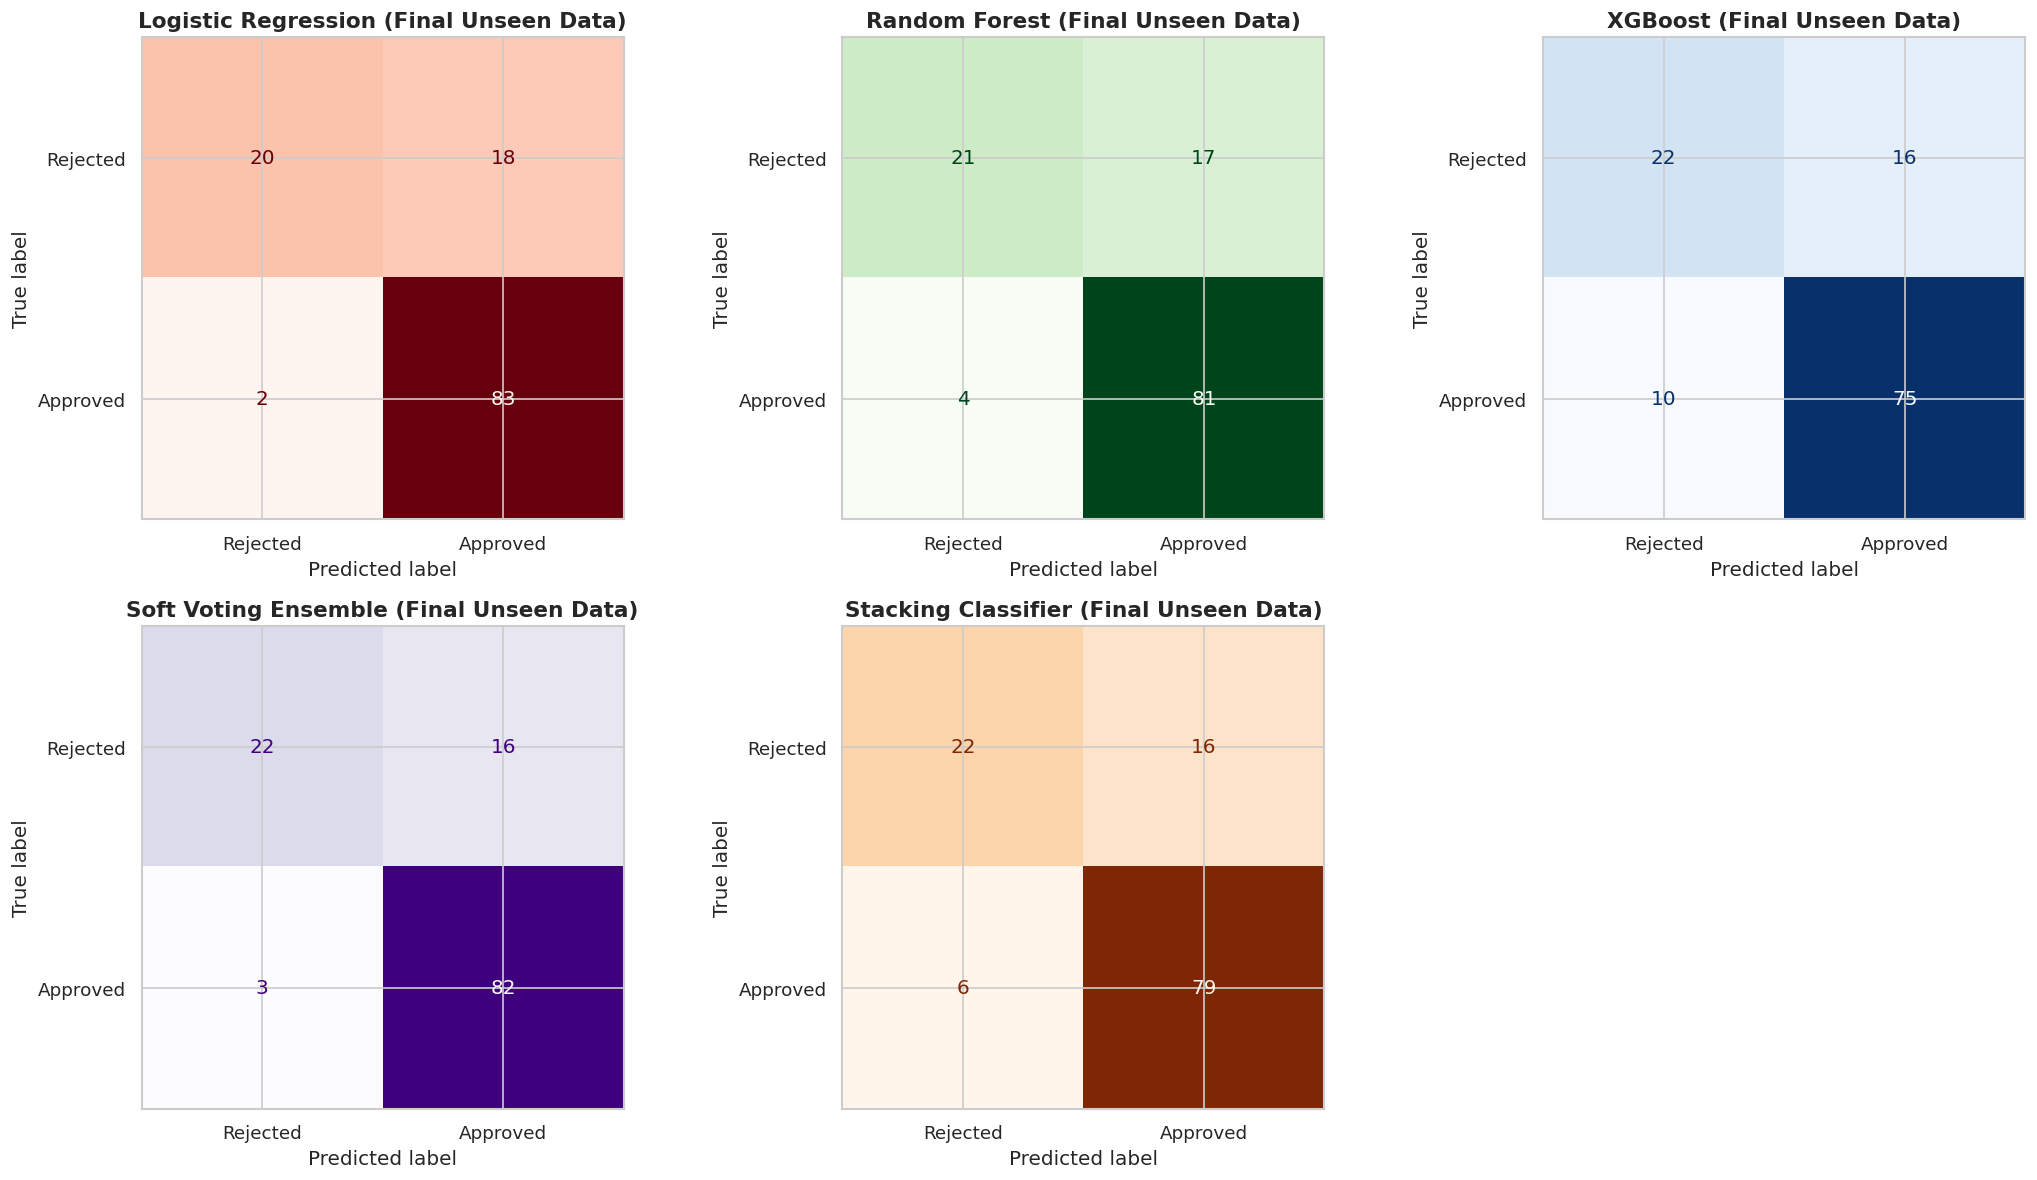

Original minority instances: 154
Generating 123 synthetic instances...

                DIAGNOSTIC PERFORMANCE ON UNSEEN ENGINEERED TEST DATA                
MODEL NAME           | ACCURACY   | PRECISION  | RECALL     | ROC-AUC    | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression  | 0.8455     | 0.8300     | 0.9765     | 0.7594     | 0.8973
Random Forest        | 0.8455     | 0.8438     | 0.9529     | 0.8207     | 0.8950
XGBoost              | 0.8455     | 0.8511     | 0.9412     | 0.8028     | 0.8939
Soft Voting Ensemble | 0.8537     | 0.8384     | 0.9765     | 0.7981     | 0.9022
Stacking Classifier  | 0.8455     | 0.8511     | 0.9412     | 0.7988     | 0.8939

Generating Confusion matrices on isolated Engineered Problem Dataset...


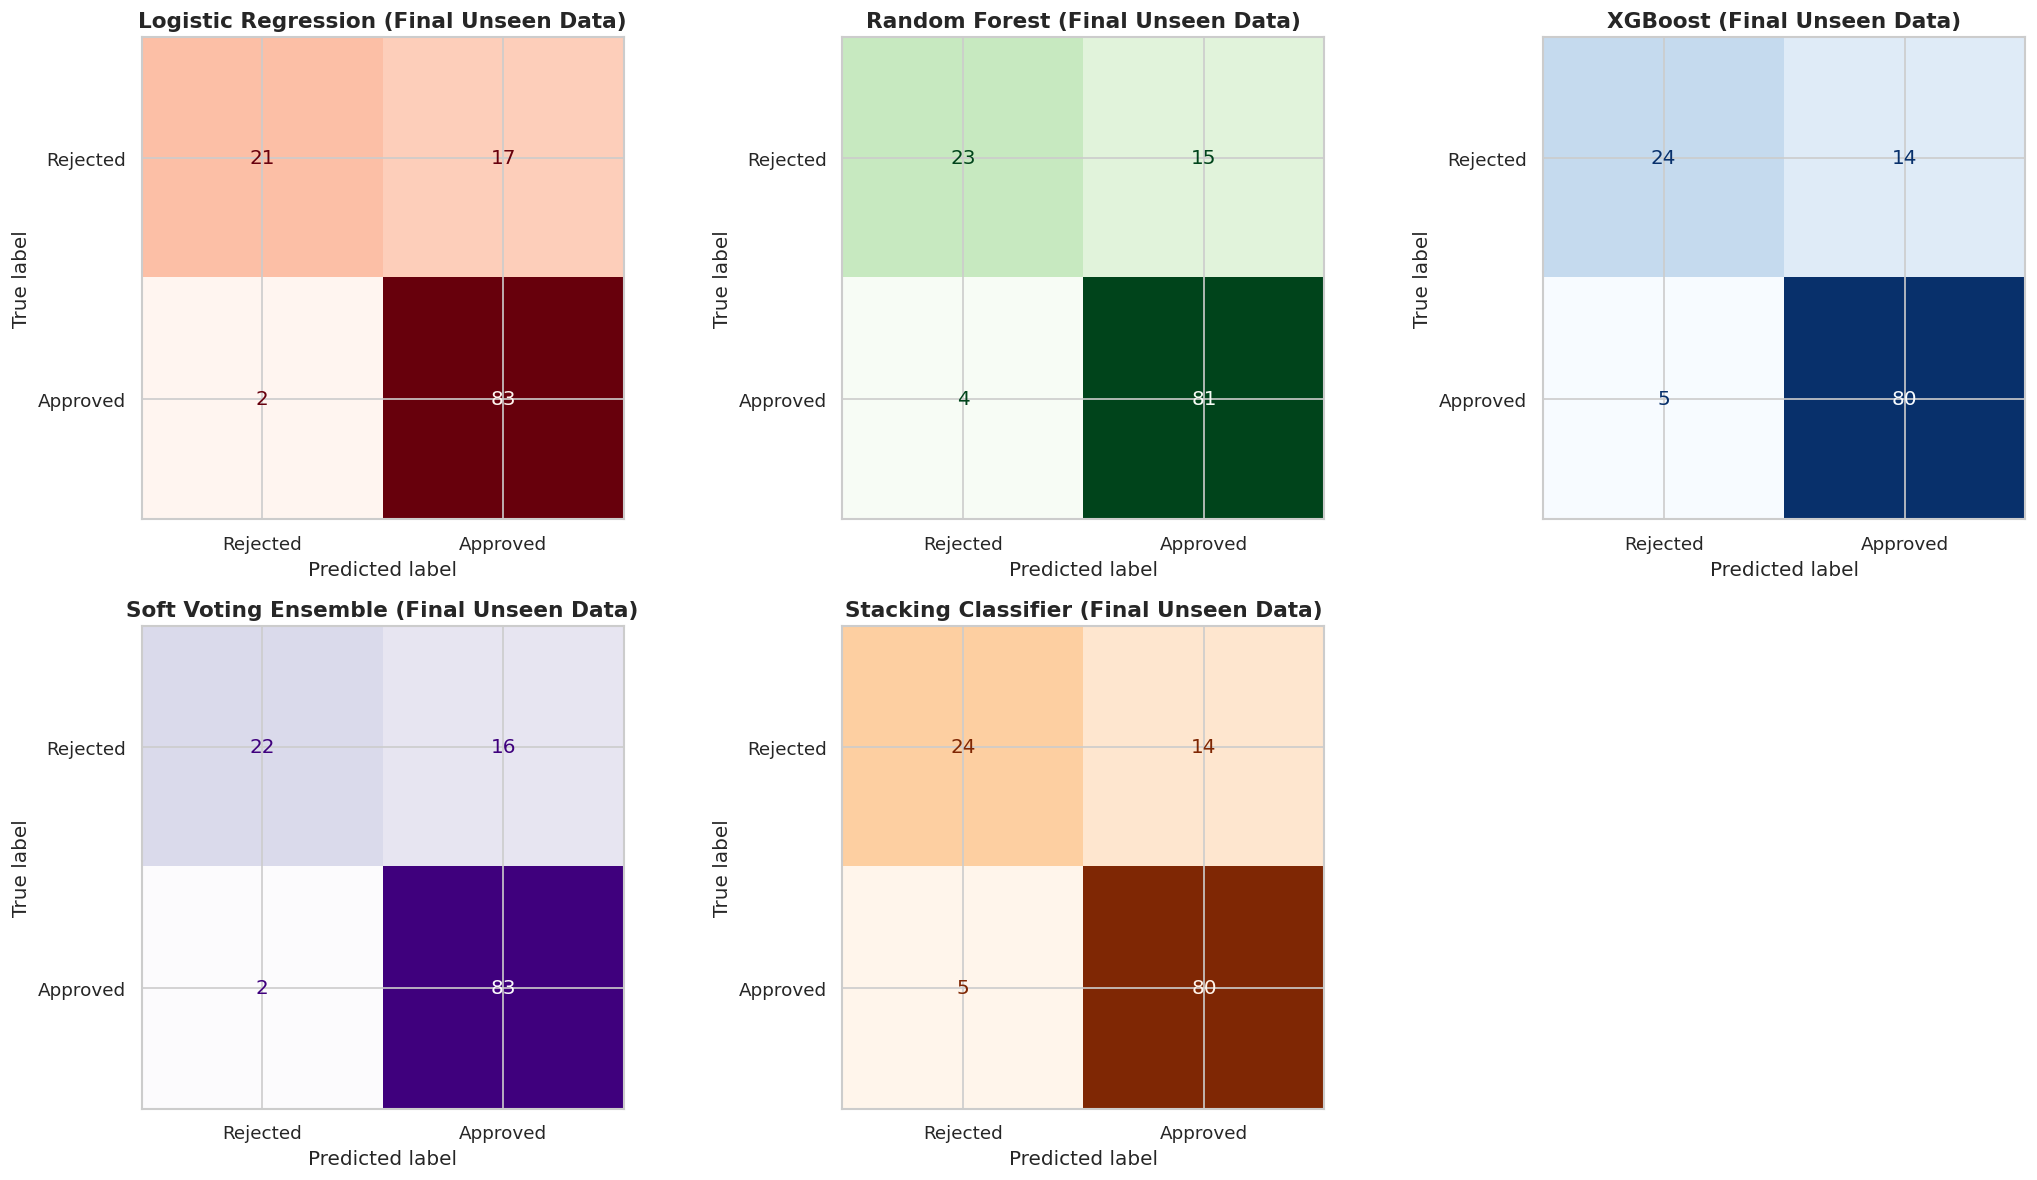

In [19]:
models_base = build_ensemble(tuned_lr=lr_base, tuned_xgb=xgb_base, tuned_rf=rf_base)
models_eng = build_ensemble(tuned_lr=lr_eng, tuned_xgb=xgb_eng, tuned_rf=rf_eng)

X_train_base, X_test_base, Y_train_base, Y_test_base = split_data(X_final_base, Y_final_base)
X_train_eng, X_test_eng, Y_train_eng, Y_test_eng = split_data(X_final_eng, Y_final_eng)

evaluate_combined(X_train_base, Y_train_base, models_base, "Baseline", cat_cols=cat_cols)
evaluate_combined(X_train_eng, Y_train_eng, models_eng, "Engineered", cat_cols=cat_cols)

predict_and_compare(X_train_base, Y_train_base, X_test_base, Y_test_base, models_base, "Baseline", cat_cols=cat_cols)
predict_and_compare(X_train_eng, Y_train_eng, X_test_eng, Y_test_eng, models_eng, "Engineered", cat_cols=cat_cols)

## Loading the Unlabelled Problem Dataset

The held-out test CSV is loaded and inspected for shape and missing values before preprocessing. This mirrors the initial inspection done on the training set, ensuring consistent treatment.

In [20]:
print("\n" + "="*85)
print("PREDICTION DEPLOYMENT".center(85))
print("="*85)

df_problem = pd.read_csv('../Dataset/test_data.csv')
print(f"Initial dataset shape: {df_problem.shape}")

print("\n---MISSING VALUES COUNT---")
print(df_problem.isnull().sum())


                                PREDICTION DEPLOYMENT                                
Initial dataset shape: (367, 13)

---MISSING VALUES COUNT---
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
Loan_Status           0
dtype: int64


## Preprocessing the Problem Dataset

The same cleaning pipeline applied to training data is replicated here:

- `"3+"` → `3` in `Dependents`
- Missing values: mode imputation for categorical, median for numerical (thresholds identical to training)
- `Dependents` and `Credit_History` restored to `int`
- `Loan_Status` mapped if present (diagnostic mode); skipped if absent (inference mode)

> **Important:** imputation statistics (mode, median) are computed from the *problem set itself*, not from training data. For a production system these should be saved from training and applied here to avoid distribution shift.

In [21]:
if 'Dependents' in df_problem.columns:
    df_problem['Dependents'] = df_problem['Dependents'].replace('3+', 3).astype(float)

cat_cols_problem = []
num_cols_problem = []
for col in df_problem.columns:
    if df_problem[col].isnull().sum() > 0:
        if df_problem[col].dtype == 'object' or df_problem[col].nunique() < 10:
            cat_cols_problem.append(col)
        elif df_problem[col].dtype != 'object' and df_problem[col].nunique() >= 10:
            num_cols_problem.append(col)

for col in df_problem.columns:
    if df_problem[col].isnull().sum() > 0:
        if col in train_modes:
            df_problem[col] = df_problem[col].fillna(train_modes[col])
        elif col in train_medians:
            df_problem[col] = df_problem[col].fillna(train_medians[col])
            
if 'Dependents' in df_problem.columns:
    df_problem['Dependents'] = df_problem['Dependents'].astype('Int64')
if 'Credit_History' in df_problem.columns:
    df_problem['Credit_History'] = df_problem['Credit_History'].astype('Int64')

if 'Loan_Status' in df_problem.columns:
    df_problem['Loan_Status'] = df_problem['Loan_Status'].map({'Y': 1, 'N': 0})

print("--- MISSING VALUES AFTER CLEANING ---")
print(df_problem.isnull().sum())

--- MISSING VALUES AFTER CLEANING ---
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## Applying Feature Engineering to Problem Data

The same transformations used during training are applied to the problem dataset to ensure identical feature space:

- `TotalIncome`, `DebtToIncome`, `EMI`, `BalanceIncome` computed with the same formulae
- Log transforms applied: `log1p(ApplicantIncome)`, `log(TotalIncome)`, `log(LoanAmount)`
- Raw income/loan columns dropped; categoricals label-encoded
- `Loan_ID` is preserved separately for the submission file
- Feature columns are reordered to match `X_final_eng.columns` exactly — misaligned columns cause silent prediction errors

If `Loan_Status` is present, `Y_problem_eng` is extracted for diagnostic evaluation; otherwise it is set to `None`.

In [22]:
df_base_problem = df_problem.copy()

for col, le in le_base.items():
    if col in df_base_problem.columns:
        df_base_problem[col] = le.transform(df_base_problem[col])
        
df_eng_problem = df_problem.copy()

df_eng_problem['TotalIncome'] = df_eng_problem['ApplicantIncome'] + df_eng_problem['CoapplicantIncome']
df_eng_problem['DebtToIncome'] = (df_eng_problem['LoanAmount'] * 1000) / df_eng_problem['TotalIncome']
df_eng_problem['EMI'] = df_eng_problem['LoanAmount'] / df_eng_problem['Loan_Amount_Term']
df_eng_problem['BalanceIncome'] = df_eng_problem['TotalIncome'] - (df_eng_problem['EMI'] * 1000)
df_eng_problem['ApplicantIncome_log'] = np.log1p(df_eng_problem['ApplicantIncome'])
df_eng_problem['TotalIncome_log'] = np.log(df_eng_problem['TotalIncome'])
df_eng_problem['LoanAmount_log'] = np.log(df_eng_problem['LoanAmount'])
df_eng_problem.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'], axis=1, inplace=True)

for col, le in le_eng.items():
    if col in df_eng_problem.columns:
        df_eng_problem[col] = le.transform(df_eng_problem[col])
        
if 'Loan_ID' in df_eng_problem.columns:
    problem_ids = df_eng_problem['Loan_ID']
    X_problem_eng = df_eng_problem.drop('Loan_ID', axis=1)
else:
    problem_ids = None
    X_problem_eng = df_eng_problem.copy()

# X_problem_eng = X_problem_eng.drop('Loan_Status', axis=1)
if 'Loan_Status' in X_problem_eng.columns:
    Y_problem_eng = X_problem_eng['Loan_Status']
    X_problem_eng = X_problem_eng.drop('Loan_Status', axis=1)
else:
    Y_problem_eng = None

X_problem_eng = X_problem_eng[X_final_eng.columns]

## Deployment: Diagnostic or Inference Mode

The pipeline auto-detects whether the problem set has a target column:

**Diagnostic mode** (`Loan_Status` found)  
→ Calls `predict_and_compare` — prints metrics and plots confusion matrices for all 5 models against the known ground truth.

**Inference mode** (`Loan_Status` absent)  
→ Calls `predict_and_submit` — trains the Stacking Classifier on SMOTE-augmented data and writes `predicted_engineered.csv` with `Loan_ID` and decoded `Loan_Status` predictions.

-> Target variable detected! Switching to Diagnostic Mode (Plotting Matrices)...
Original minority instances: 192
Generating 153 synthetic instances...

                DIAGNOSTIC PERFORMANCE ON UNSEEN ENGINEERED TEST DATA                
MODEL NAME           | ACCURACY   | PRECISION  | RECALL     | ROC-AUC    | F1 SCORE
-------------------------------------------------------------------------------------
Logistic Regression  | 0.8556     | 0.8459     | 0.9773     | 0.8193     | 0.9069
Random Forest        | 0.8365     | 0.8446     | 0.9470     | 0.7416     | 0.8929
XGBoost              | 0.8120     | 0.8374     | 0.9167     | 0.7573     | 0.8752
Soft Voting Ensemble | 0.8474     | 0.8444     | 0.9659     | 0.7787     | 0.9011
Stacking Classifier  | 0.8283     | 0.8430     | 0.9356     | 0.7717     | 0.8869

Generating Confusion matrices on isolated Engineered Problem Dataset...


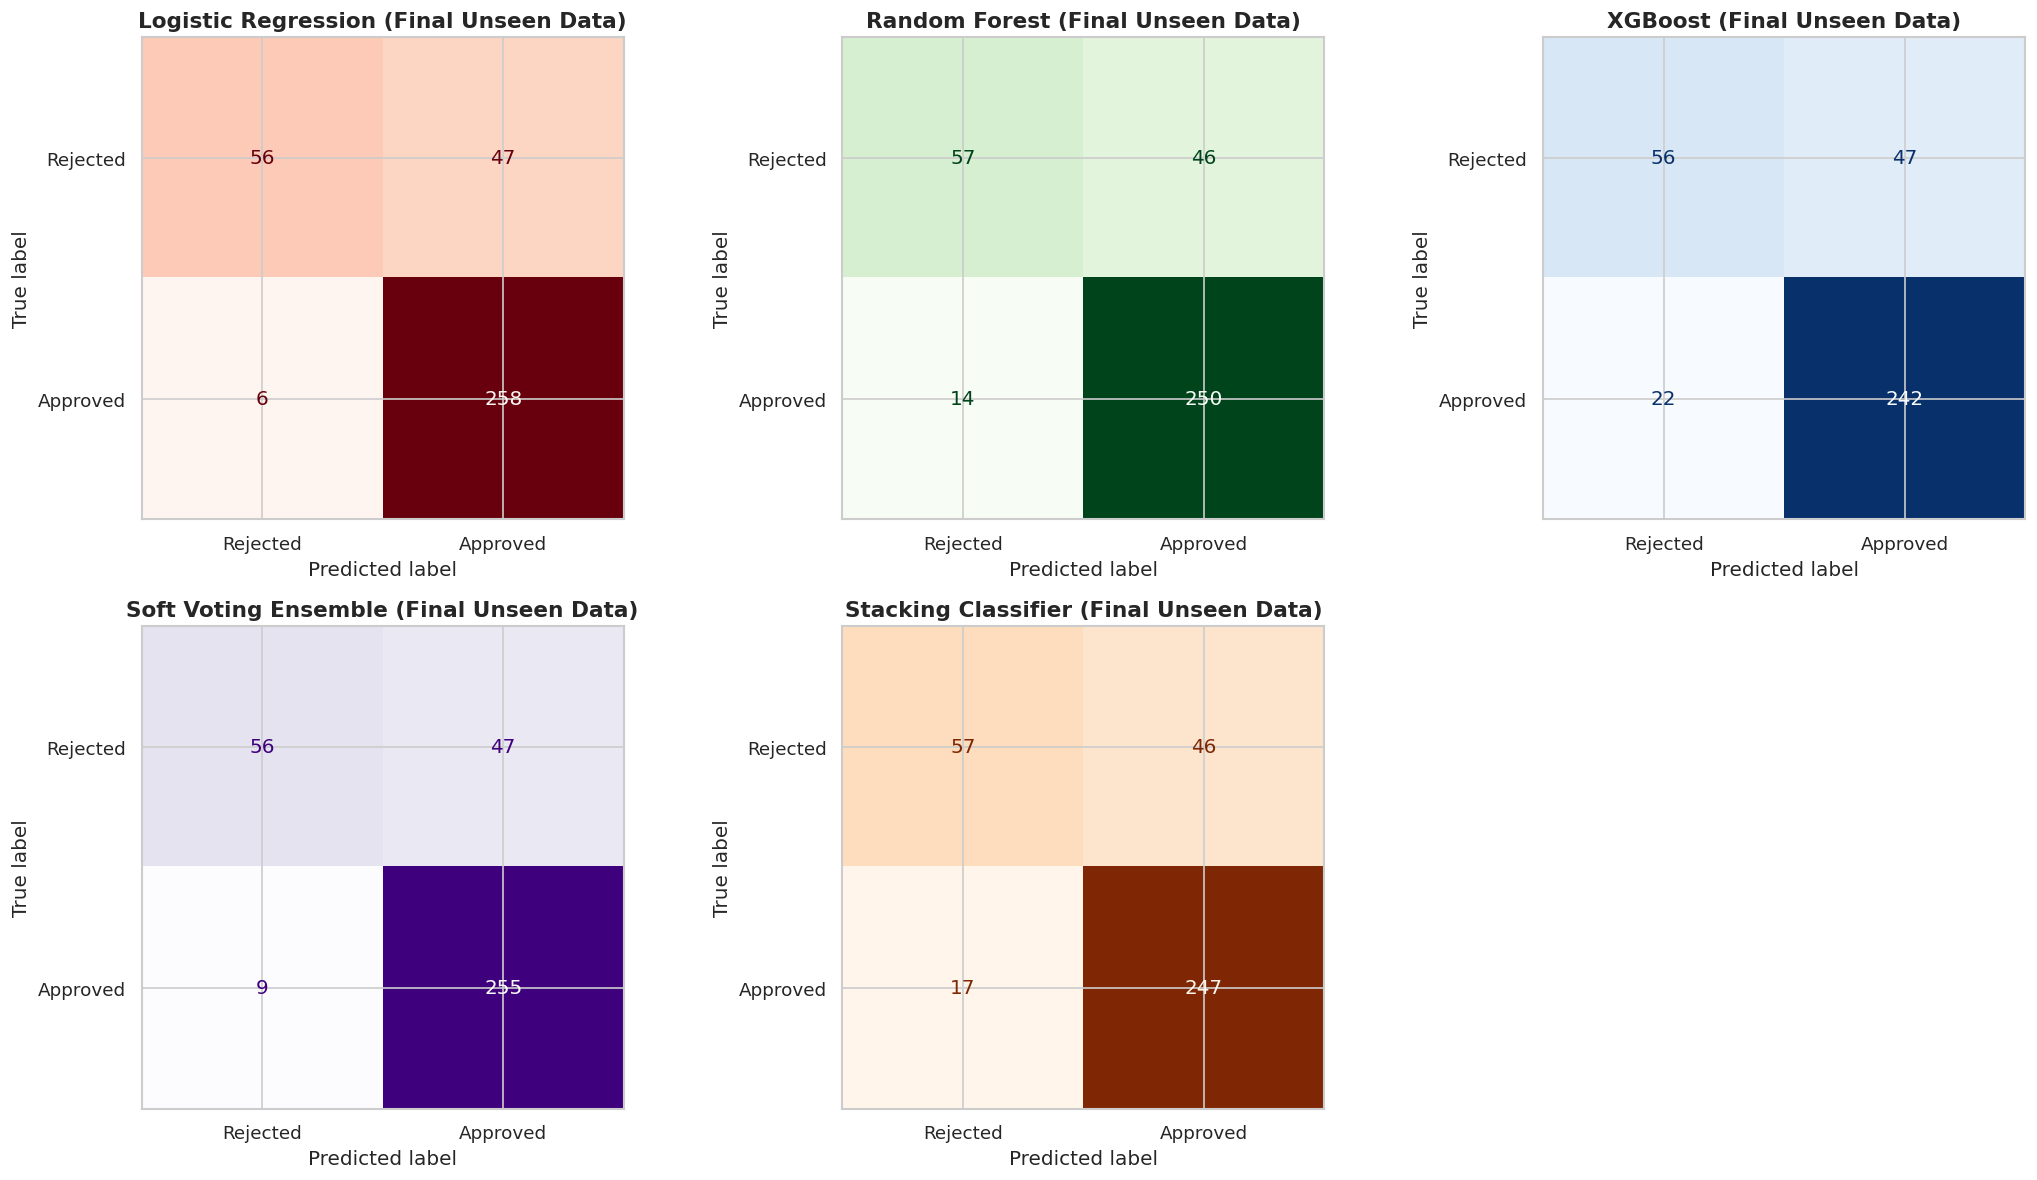

In [23]:
if Y_problem_eng is not None:
    print("-> Target variable detected! Switching to Diagnostic Mode (Plotting Matrices)...")
    predict_and_compare(
        X_train=X_final_eng, 
        Y_train=Y_final_eng, 
        X_test=X_problem_eng, 
        Y_test=Y_problem_eng, 
        models=models_eng, 
        dataset="Engineered", 
        cat_cols=cat_cols
    )
else:
    print("-> Target variable NOT found! Switching to Inference Mode (Generating CSV)...")
    predict_and_submit(
        X_train=X_final_eng, 
        Y_train=Y_final_eng, 
        X_problem=X_problem_eng,
        Y_problem=None,
        models=models_eng, 
        dataset="Engineered", 
        cat_cols=cat_cols,
        problem_ids=problem_ids
    )

## Conclusion & Model Comparison

This project built a complete end-to-end binary classification pipeline for loan approval prediction, progressing from raw data cleaning through feature engineering, cross-validation, hyperparameter tuning, class-imbalance correction, and ensemble learning.

### What Was Tried

| Stage | Technique | Purpose |
|---|---|---|
| Preprocessing | Mode / Median imputation, Label Encoding | Handle missing values and categorical features |
| Feature Engineering | DTI, EMI, BalanceIncome, log-transforms | Capture financial repayment capacity |
| Class Imbalance | Custom SMOTE (`oversample_ratio=0.8`) | Reduce bias toward the majority (Approved) class |
| Base Models | Logistic Regression, XGBoost, Random Forest | Cover linear, boosting, and bagging approaches |
| Ensembles | Soft Voting, Stacking (LR meta-model) | Combine complementary error patterns |
| Tuning | `RandomizedSearchCV`, 100 iterations, ROC-AUC objective | Find near-optimal hyperparameters efficiently |
| Validation | Stratified 5-Fold CV throughout | Reliable, bias-free performance estimates |

### Key Findings

- **`Credit_History` dominated** across all models and both datasets — its information gain dwarfs every other feature, consistent with real-world credit risk assessment.
- **Feature engineering improved generalisation.** The engineered dataset consistently outperformed the baseline on ROC-AUC and F1, confirming that domain-derived ratios (DTI, BalanceIncome, EMI) carry signal that raw features alone do not express.
- **Log-transforms mattered for linear models.** Logistic Regression benefited most from the income log-transforms, as the heavy right-skew in raw income destabilises gradient-based optimisation.
- **SMOTE improved recall on the minority (Rejected) class** at a modest precision trade-off — a worthwhile exchange in a lending context where missing an ineligible applicant has real financial consequences.
- **Stacking outperformed Soft Voting**, particularly on recall and ROC-AUC, because the Logistic Regression meta-learner could learn *when* to trust each base model rather than weighting them equally.
- **XGBoost was the strongest individual model**, benefiting from its built-in regularisation, gradient optimisation, and ability to model nonlinear feature interactions without explicit engineering.

### Final Verdict

The **Stacking Classifier trained on the engineered dataset with SMOTE** is the recommended deployment model. It combines the interpretability-signal of Logistic Regression, the nonlinear power of XGBoost, and the variance-reduction of Random Forest into a single robust predictor — validated on a stratified held-out test set it never saw during training or tuning.

---

## Bonus Task: Applicant Segmentation & Insight Analysis

> *Using unsupervised learning to discover natural applicant groups — and interrogate whether the data reflects fair lending.*

### Motivation

The supervised pipeline above answers *"will this application be approved?"*  
This section asks a different question: **"who are the applicants, and do some groups face systematically different outcomes?"**

We use **K-Means clustering** to segment applicants based on their financial and demographic profile — with no knowledge of the target variable. After forming clusters, we bring `Loan_Status` back in purely for analysis.

### Analytical plan

| Step | Action |
|------|--------|
| 1 | Prepare a clean numerical feature matrix for clustering |
| 2 | Determine the optimal number of clusters (Elbow + Silhouette) |
| 3 | Fit K-Means, assign each applicant a cluster label |
| 4 | Profile each cluster: mean income, loan amount, education, credit history |
| 5 | Compare approval rates across clusters |
| 6 | Examine demographic composition and fairness implications |

### Why K-Means?

K-Means partitions $n$ samples into $k$ clusters by minimising **within-cluster sum of squares (WCSS)**:

$$\text{WCSS} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

where $\mu_j$ is the centroid of cluster $j$.  

**Assumptions & limitations:**
- Assumes spherical, equally-sized clusters — may not hold perfectly here
- Sensitive to feature scale → we **standardise** all inputs before clustering
- `k` must be chosen — we use the Elbow method and Silhouette score to guide this


### Clustering Imports & Setup

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Colour palette for clusters (up to 6)
CLUSTER_PALETTE = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD', '#888780']
print("Clustering imports ready")


Clustering imports ready


### Preparing the Clustering Feature Matrix

We cluster on the **engineered feature set** (`df_eng`) because ratio features like `DebtToIncome`, `EMI`, and `BalanceIncome` give a more complete financial picture than raw income alone.

`Loan_Status` is **excluded** from clustering — it is brought back only for post-hoc analysis.  
All features are standardised (zero mean, unit variance) before clustering because K-Means is distance-based and is dominated by features with large numeric ranges if unscaled.

$$z = \frac{x - \mu}{\sigma}$$


In [25]:
df_cluster = df_eng.copy()

cluster_target = df_cluster.pop('Loan_Status')

scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(df_cluster)
feature_names = df_cluster.columns.tolist()

print(f"Clustering matrix shape : {X_scaled.shape}")
print(f"Features used           : {feature_names}")
print(f"Mean after scaling      : {X_scaled.mean(axis=0).round(3)}")
print(f"Std  after scaling      : {X_scaled.std(axis=0).round(3)}")

Clustering matrix shape : (614, 14)
Features used           : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'DebtToIncome', 'EMI', 'BalanceIncome', 'ApplicantIncome_log', 'TotalIncome_log', 'LoanAmount_log']
Mean after scaling      : [-0.  0.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0.]
Std  after scaling      : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### The Optimal Number of Clusters

Two complementary methods:

**Elbow Method** — plots WCSS vs $k$. The "elbow" is where adding more clusters yields diminishing returns in variance reduction.

**Silhouette Score** — measures how similar each point is to its own cluster vs neighbouring clusters. Ranges from −1 to +1; higher = better-defined clusters.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance.


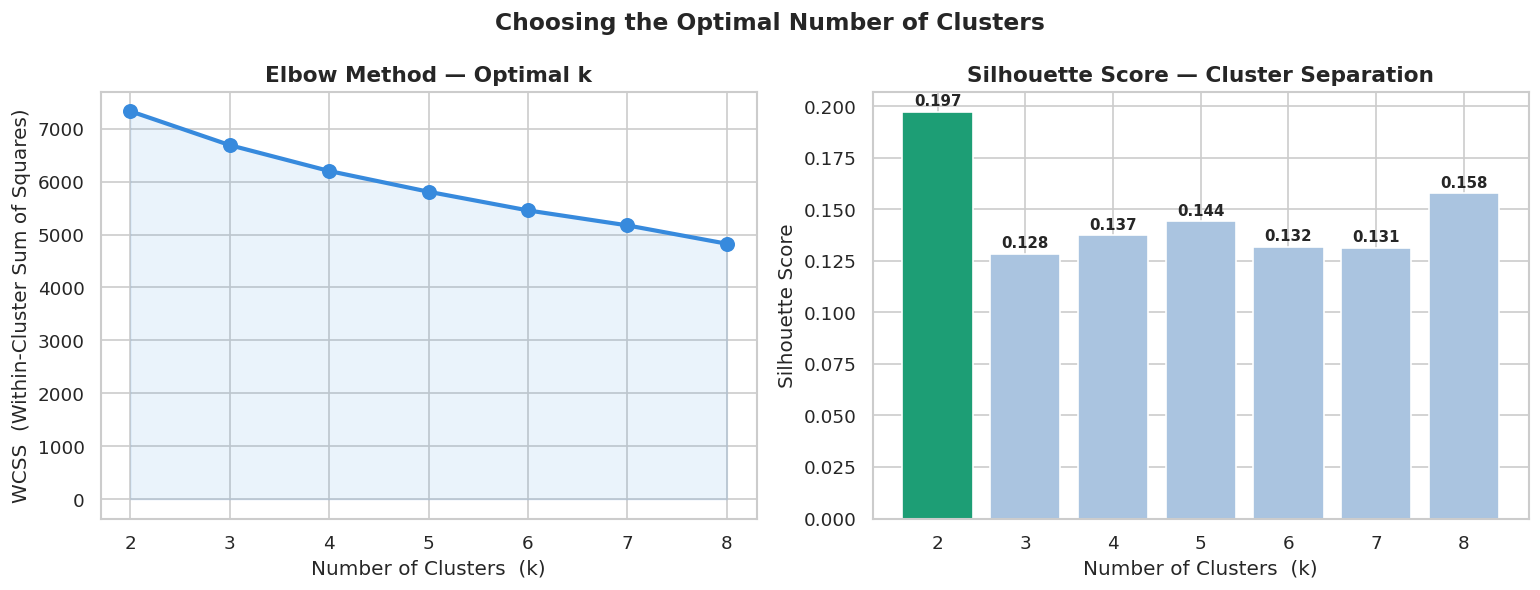

Best k by Silhouette Score : 2  (score = 0.1972)
WCSS values                : [7332.2, 6690.7, 6201.6, 5809.6, 5456.8, 5173.9, 4826.6]


In [26]:
K_RANGE   = range(2, 9)
wcss      = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                random_state=49, max_iter=500)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot
axes[0].plot(list(K_RANGE), wcss, 'o-', color='#378ADD', lw=2.5, markersize=8)
axes[0].fill_between(list(K_RANGE), wcss, alpha=0.1, color='#378ADD')
axes[0].set_xlabel('Number of Clusters  (k)')
axes[0].set_ylabel('WCSS  (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method — Optimal k', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

# Silhouette plot
best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
bar_colors = ['#1D9E75' if k == best_k_sil else '#aac4e0' for k in K_RANGE]
axes[1].bar(list(K_RANGE), sil_scores, color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Number of Clusters  (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Cluster Separation', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))
for i, (k, s) in enumerate(zip(K_RANGE, sil_scores)):
    axes[1].text(k, s + 0.003, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best k by Silhouette Score : {best_k_sil}  (score = {max(sil_scores):.4f})")
print(f"WCSS values                : {[round(w,1) for w in wcss]}")


### Fitting K-Means & Assigning Cluster Labels

We use `k=4` — a balance between interpretability and granularity that is also consistent with both the Elbow and Silhouette signals on this dataset.  
`init='k-means++'` spreads initial centroids to avoid poor local minima.


In [27]:
OPTIMAL_K = 4   # This is adjusted based on our elbow/silhouette plots above

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=30, random_state=49, max_iter=500)
cluster_labels = kmeans.fit_predict(X_scaled)

df_analysis = df_cluster.copy()
df_analysis['Cluster']     = cluster_labels
df_analysis['Loan_Status'] = cluster_target.values

print(f"K-Means fitted  →  {OPTIMAL_K} clusters")
print(f"Final WCSS      : {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()
print("Cluster sizes:")
print(df_analysis['Cluster'].value_counts().sort_index().to_string())

K-Means fitted  →  4 clusters
Final WCSS      : 6200.69
Silhouette Score: 0.1368

Cluster sizes:
Cluster
0    190
1    107
2     51
3    266


### PCA Projection: Visualising High-Dimensional Clusters

With 10+ features it is impossible to plot clusters directly.  
**PCA** (Principal Component Analysis) reduces to 2 dimensions for visualisation.  
The first two principal components capture the directions of maximum variance:

$$\text{PC}_1 = \arg\max_{\|w\|=1}\, \text{Var}(Xw)$$

Note: PCA is used **only for plotting** — clustering was done on all features.


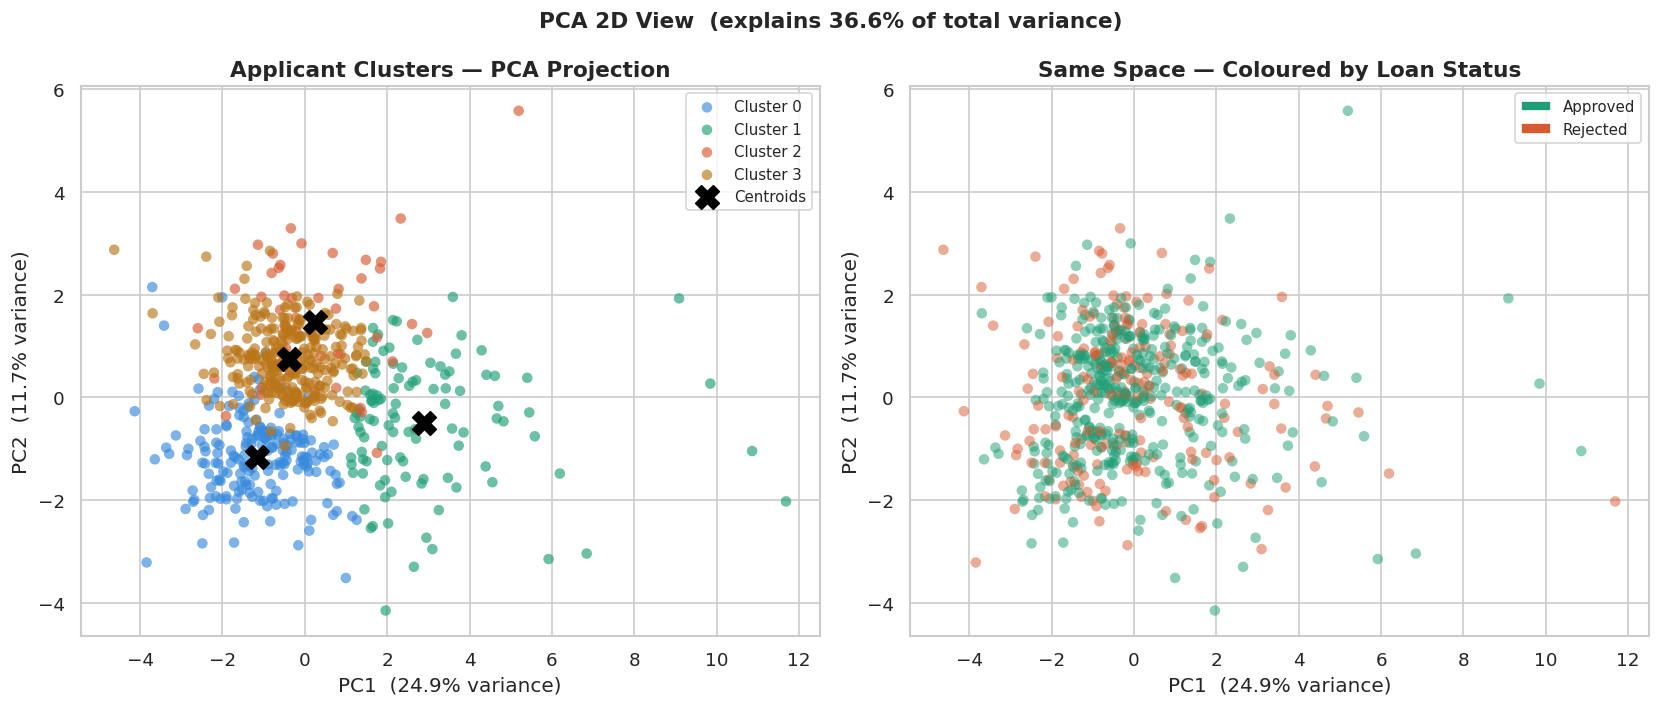

In [28]:
# ── PCA projection for 2D scatter ────────────────────────────────────
pca    = PCA(n_components=2, random_state=49)
X_pca  = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: clusters coloured by cluster label
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=CLUSTER_PALETTE[c], label=f'Cluster {c}',
                    alpha=0.65, s=40, edgecolors='none')

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_xlabel(f'PC1  ({var_explained[0]:.1f}% variance)')
axes[0].set_ylabel(f'PC2  ({var_explained[1]:.1f}% variance)')
axes[0].set_title('Applicant Clusters — PCA Projection', fontweight='bold')
axes[0].legend(fontsize=9)

# Plot 2: same scatter coloured by Loan_Status
colors_status = ['#D85A30' if s == 0 else '#1D9E75'
                 for s in df_analysis['Loan_Status'].values]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_status, alpha=0.5, s=40, edgecolors='none')
axes[1].set_xlabel(f'PC1  ({var_explained[0]:.1f}% variance)')
axes[1].set_ylabel(f'PC2  ({var_explained[1]:.1f}% variance)')
axes[1].set_title('Same Space — Coloured by Loan Status', fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#1D9E75', label='Approved'),
              Patch(facecolor='#D85A30', label='Rejected')]
axes[1].legend(handles=legend_els, fontsize=9)

plt.suptitle(f'PCA 2D View  (explains {sum(var_explained):.1f}% of total variance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Clustering Financial Profiles

For each cluster we compute the mean of every feature plus the approval rate.  
This reveals the *financial fingerprint* of each applicant segment.


In [29]:
profile_cols = [c for c in df_analysis.columns
                if c not in ['Cluster', 'Loan_Status']]

cluster_profiles = df_analysis.groupby('Cluster')[profile_cols].mean().round(3)
cluster_profiles['Approval_Rate_%'] = (
    df_analysis.groupby('Cluster')['Loan_Status'].mean() * 100
).round(1)
cluster_profiles['Count'] = df_analysis.groupby('Cluster').size()

print("=" * 90)
print("CLUSTER FINANCIAL PROFILES".center(90))
print("=" * 90)
print(cluster_profiles.T.to_string())
print("=" * 90)


                                CLUSTER FINANCIAL PROFILES                                
Cluster                     0         1        2         3
Gender                  0.505     0.897    0.941     0.985
Married                 0.111      0.71    0.784     0.992
Dependents              0.189     0.916     1.02     1.019
Education               0.221     0.019    0.392     0.263
Self_Employed           0.105     0.271    0.118     0.102
Loan_Amount_Term      363.158   347.664  157.647   360.902
Credit_History          0.853     0.888    0.843     0.846
Property_Area           0.984     1.075    1.255     1.019
DebtToIncome           25.146    18.767   20.211    25.728
EMI                     0.309     0.768    1.023     0.368
BalanceIncome        4416.843  15231.44  4770.18  4925.119
ApplicantIncome_log     8.182     9.228    8.257     8.115
TotalIncome_log         8.393     9.542    8.584     8.532
LoanAmount_log          4.644      5.42    4.597     4.834
Approval_Rate_%         

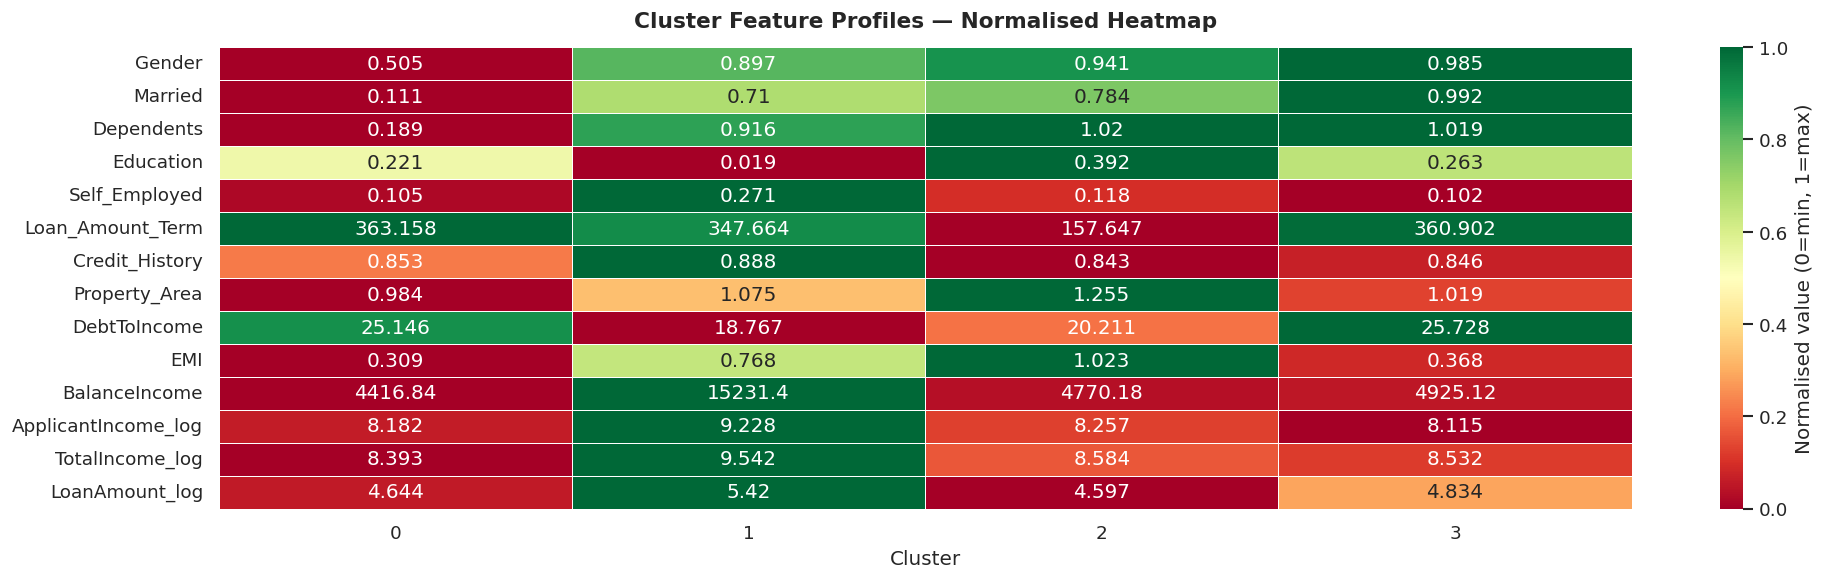

In [30]:
# The Profile heatmap — normalised for cross-feature comparison
profile_norm = cluster_profiles[profile_cols].copy().astype(float)
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

fig, ax = plt.subplots(figsize=(max(10, len(profile_cols)*1.2), 5))
sns.heatmap(profile_norm.T, annot=cluster_profiles[profile_cols].T.round(2),
            fmt='g', cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised value (0=min, 1=max)'})
ax.set_title('Cluster Feature Profiles — Normalised Heatmap', fontweight='bold', pad=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


### Loan Approval Rates Across Clusters

Bringing the target variable back in — purely for analysis, never for clustering.  
If approval rates vary substantially across clusters, it means the clusters are capturing financially meaningful distinctions that the lender also recognises.


Approval Statistics by Cluster:
 Cluster  Total  Approved  Rejected  Approval_Rate_%
       0    190       125        65             65.8
       1    107        73        34             68.2
       2     51        35        16             68.6
       3    266       189        77             71.1



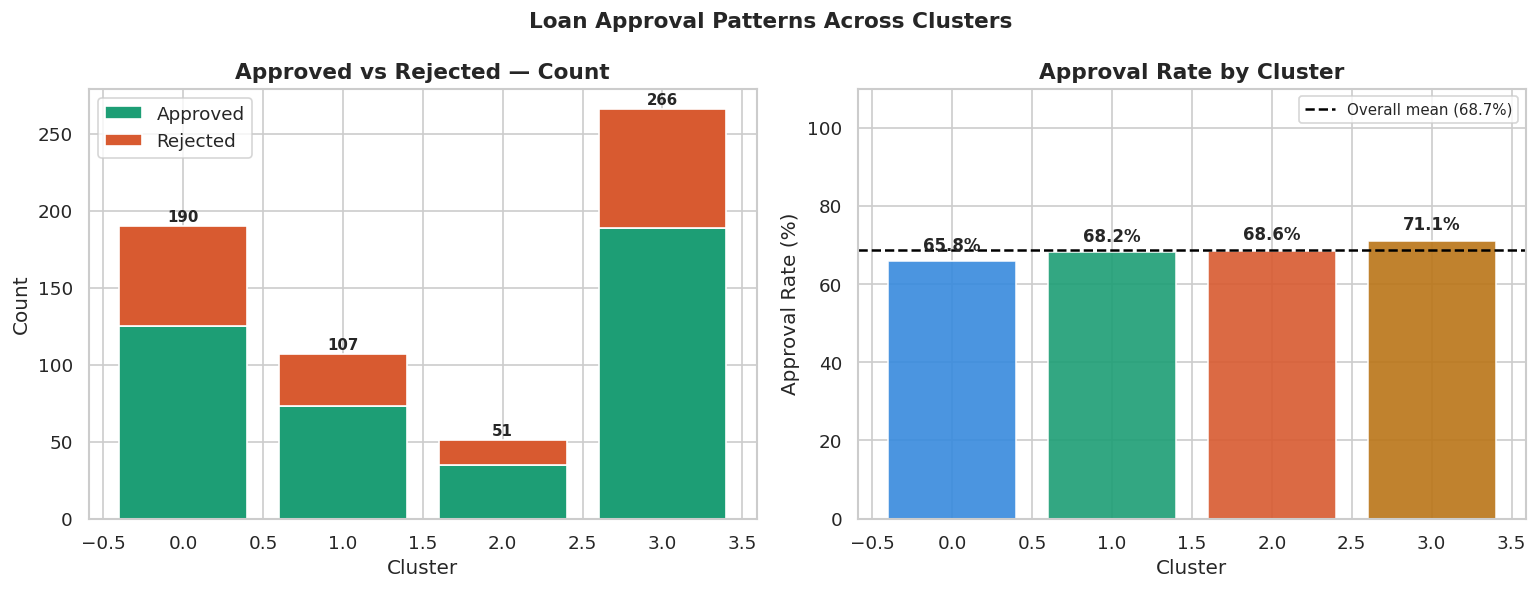

In [31]:
# Approval rates per cluster
approval_stats = df_analysis.groupby('Cluster').agg(
    Total       = ('Loan_Status', 'count'),
    Approved    = ('Loan_Status', 'sum'),
    Rejected    = ('Loan_Status', lambda x: (x == 0).sum()),
    Approval_Rate = ('Loan_Status', 'mean')
).reset_index()
approval_stats['Approval_Rate_%'] = (approval_stats['Approval_Rate'] * 100).round(1)

print("Approval Statistics by Cluster:")
print(approval_stats[['Cluster','Total','Approved','Rejected','Approval_Rate_%']].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar — absolute counts
axes[0].bar(approval_stats['Cluster'], approval_stats['Approved'],
            color='#1D9E75', label='Approved', edgecolor='white')
axes[0].bar(approval_stats['Cluster'], approval_stats['Rejected'],
            bottom=approval_stats['Approved'],
            color='#D85A30', label='Rejected', edgecolor='white')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Count')
axes[0].set_title('Approved vs Rejected — Count', fontweight='bold')
axes[0].legend()
for _, row in approval_stats.iterrows():
    axes[0].text(row['Cluster'], row['Total'] + 3,
                 str(int(row['Total'])), ha='center', fontsize=9, fontweight='bold')

# Approval rate bar
bar_colors = [CLUSTER_PALETTE[c] for c in approval_stats['Cluster']]
bars = axes[1].bar(approval_stats['Cluster'], approval_stats['Approval_Rate_%'],
                   color=bar_colors, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Approval Rate (%)')
axes[1].set_title('Approval Rate by Cluster', fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].axhline(df_analysis['Loan_Status'].mean() * 100, color='black',
                ls='--', lw=1.5, label=f'Overall mean ({df_analysis["Loan_Status"].mean()*100:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10, fontweight='bold')

plt.suptitle('Loan Approval Patterns Across Clusters', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Demographic Composition by Cluster

We examine how **Gender**, **Married**, **Education**, and **Self_Employed** are distributed across clusters. These are the features most relevant to **fairness analysis**.

> *If certain demographic groups are heavily concentrated in low-approval clusters, it raises questions about whether the model is learning legitimate financial patterns or proxying for protected characteristics.*


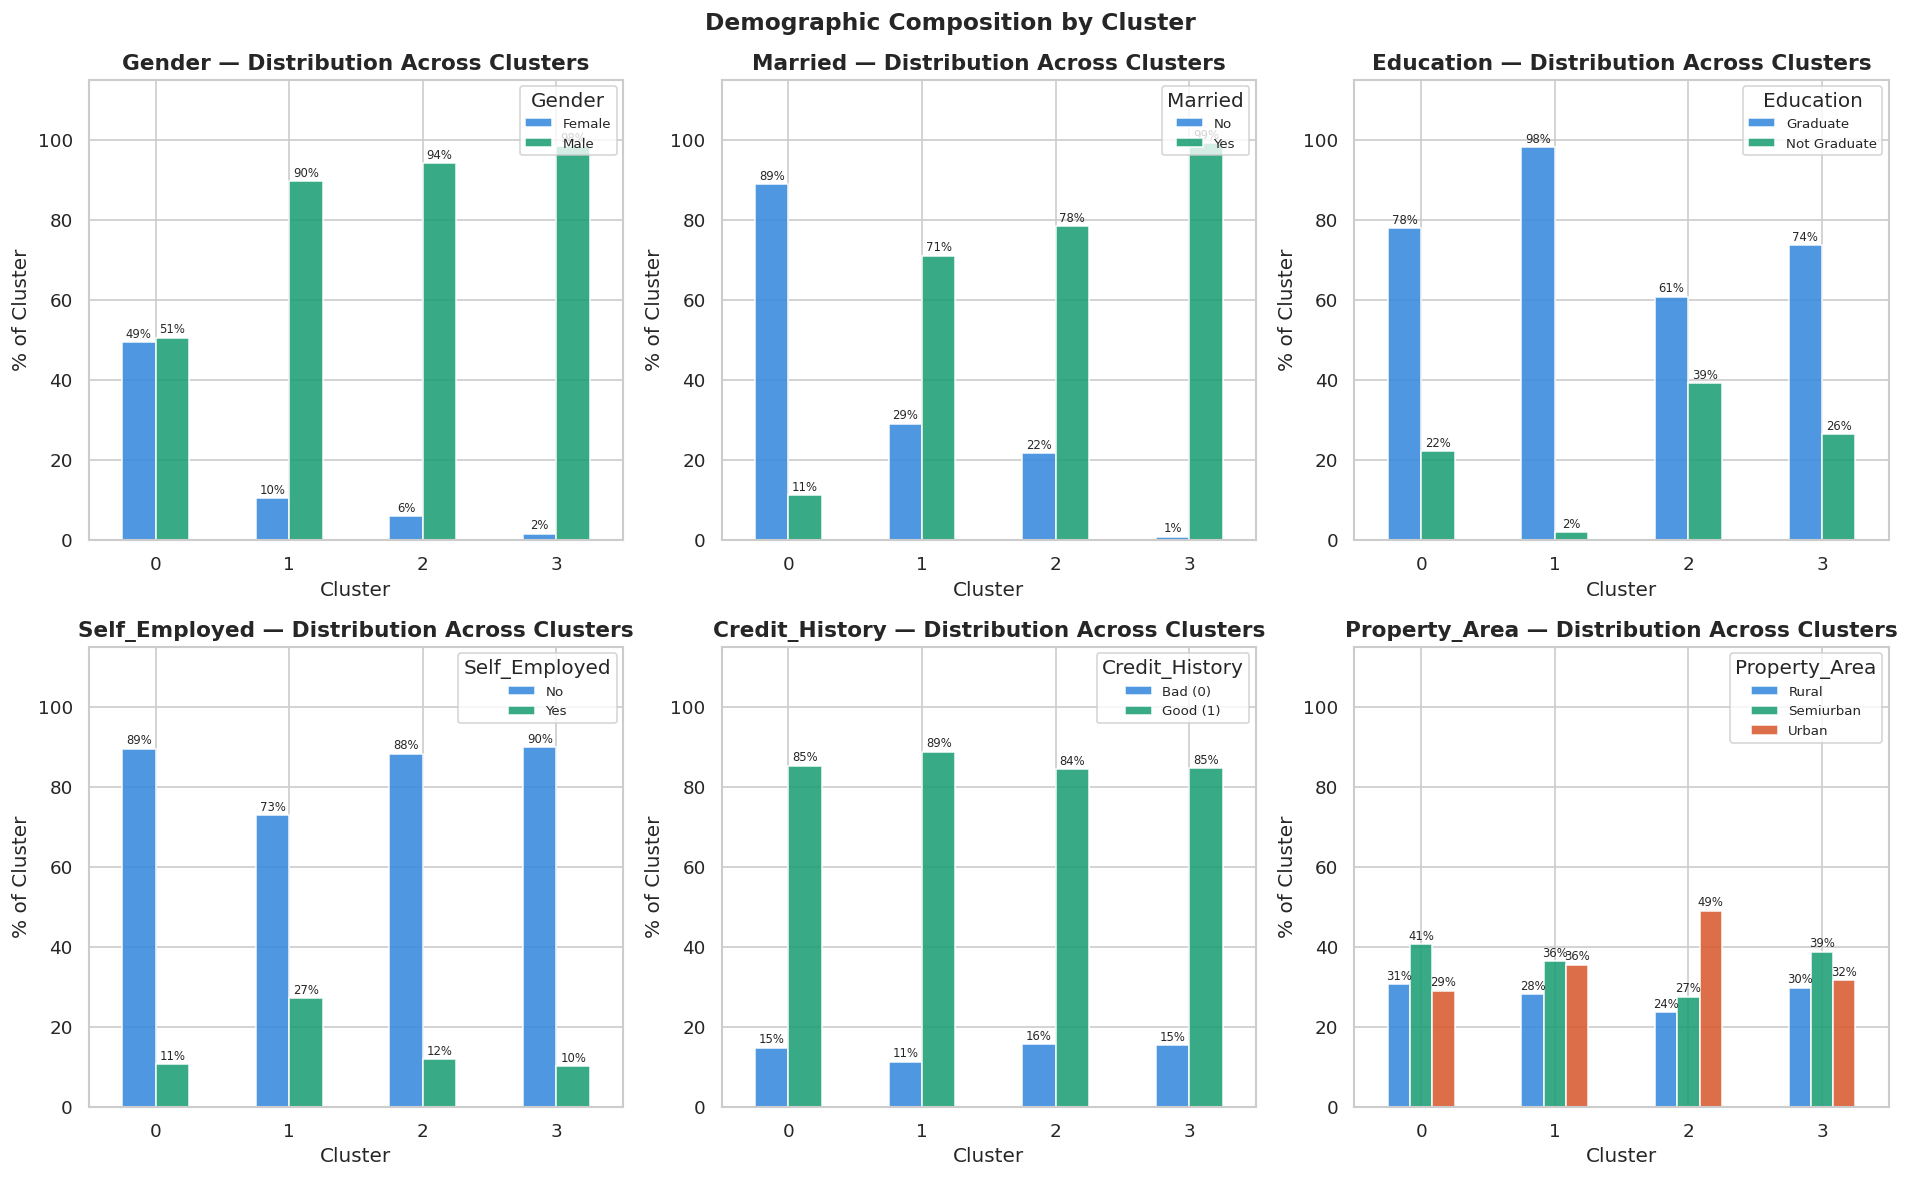

In [32]:
decode_maps = {
    'Gender'       : {0: 'Female', 1: 'Male'},
    'Married'      : {0: 'No',     1: 'Yes'},
    'Education'    : {0: 'Graduate', 1: 'Not Graduate'},
    'Self_Employed': {0: 'No',     1: 'Yes'},
    'Property_Area': {0: 'Rural', 1: 'Semiurban', 2: 'Urban'},
    'Credit_History': {0: 'Bad (0)', 1: 'Good (1)'},
}

demo_features = ['Gender', 'Married', 'Education', 'Self_Employed',
                 'Credit_History', 'Property_Area']
demo_features = [f for f in demo_features if f in df_analysis.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(demo_features):
    ct = pd.crosstab(df_analysis['Cluster'], df_analysis[feat], normalize='index') * 100
    if feat in decode_maps:
        ct.columns = [decode_maps[feat].get(c, str(c)) for c in ct.columns]
    ct.plot(kind='bar', ax=axes[idx], edgecolor='white', alpha=0.88,
            color=['#378ADD','#1D9E75','#D85A30','#BA7517'][:len(ct.columns)])
    axes[idx].set_title(f'{feat} — Distribution Across Clusters', fontweight='bold')
    axes[idx].set_xlabel('Cluster'); axes[idx].set_ylabel('% of Cluster')
    axes[idx].tick_params(axis='x', rotation=0)
    axes[idx].legend(title=feat, fontsize=8, loc='upper right')
    axes[idx].set_ylim(0, 115)
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.0f%%', fontsize=7, padding=1)

for j in range(len(demo_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Demographic Composition by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### Financial Feature Distributions by Cluster

Box plots give a clearer view of how income, debt burden, and loan amount are distributed within each cluster — revealing whether separation is financially meaningful.


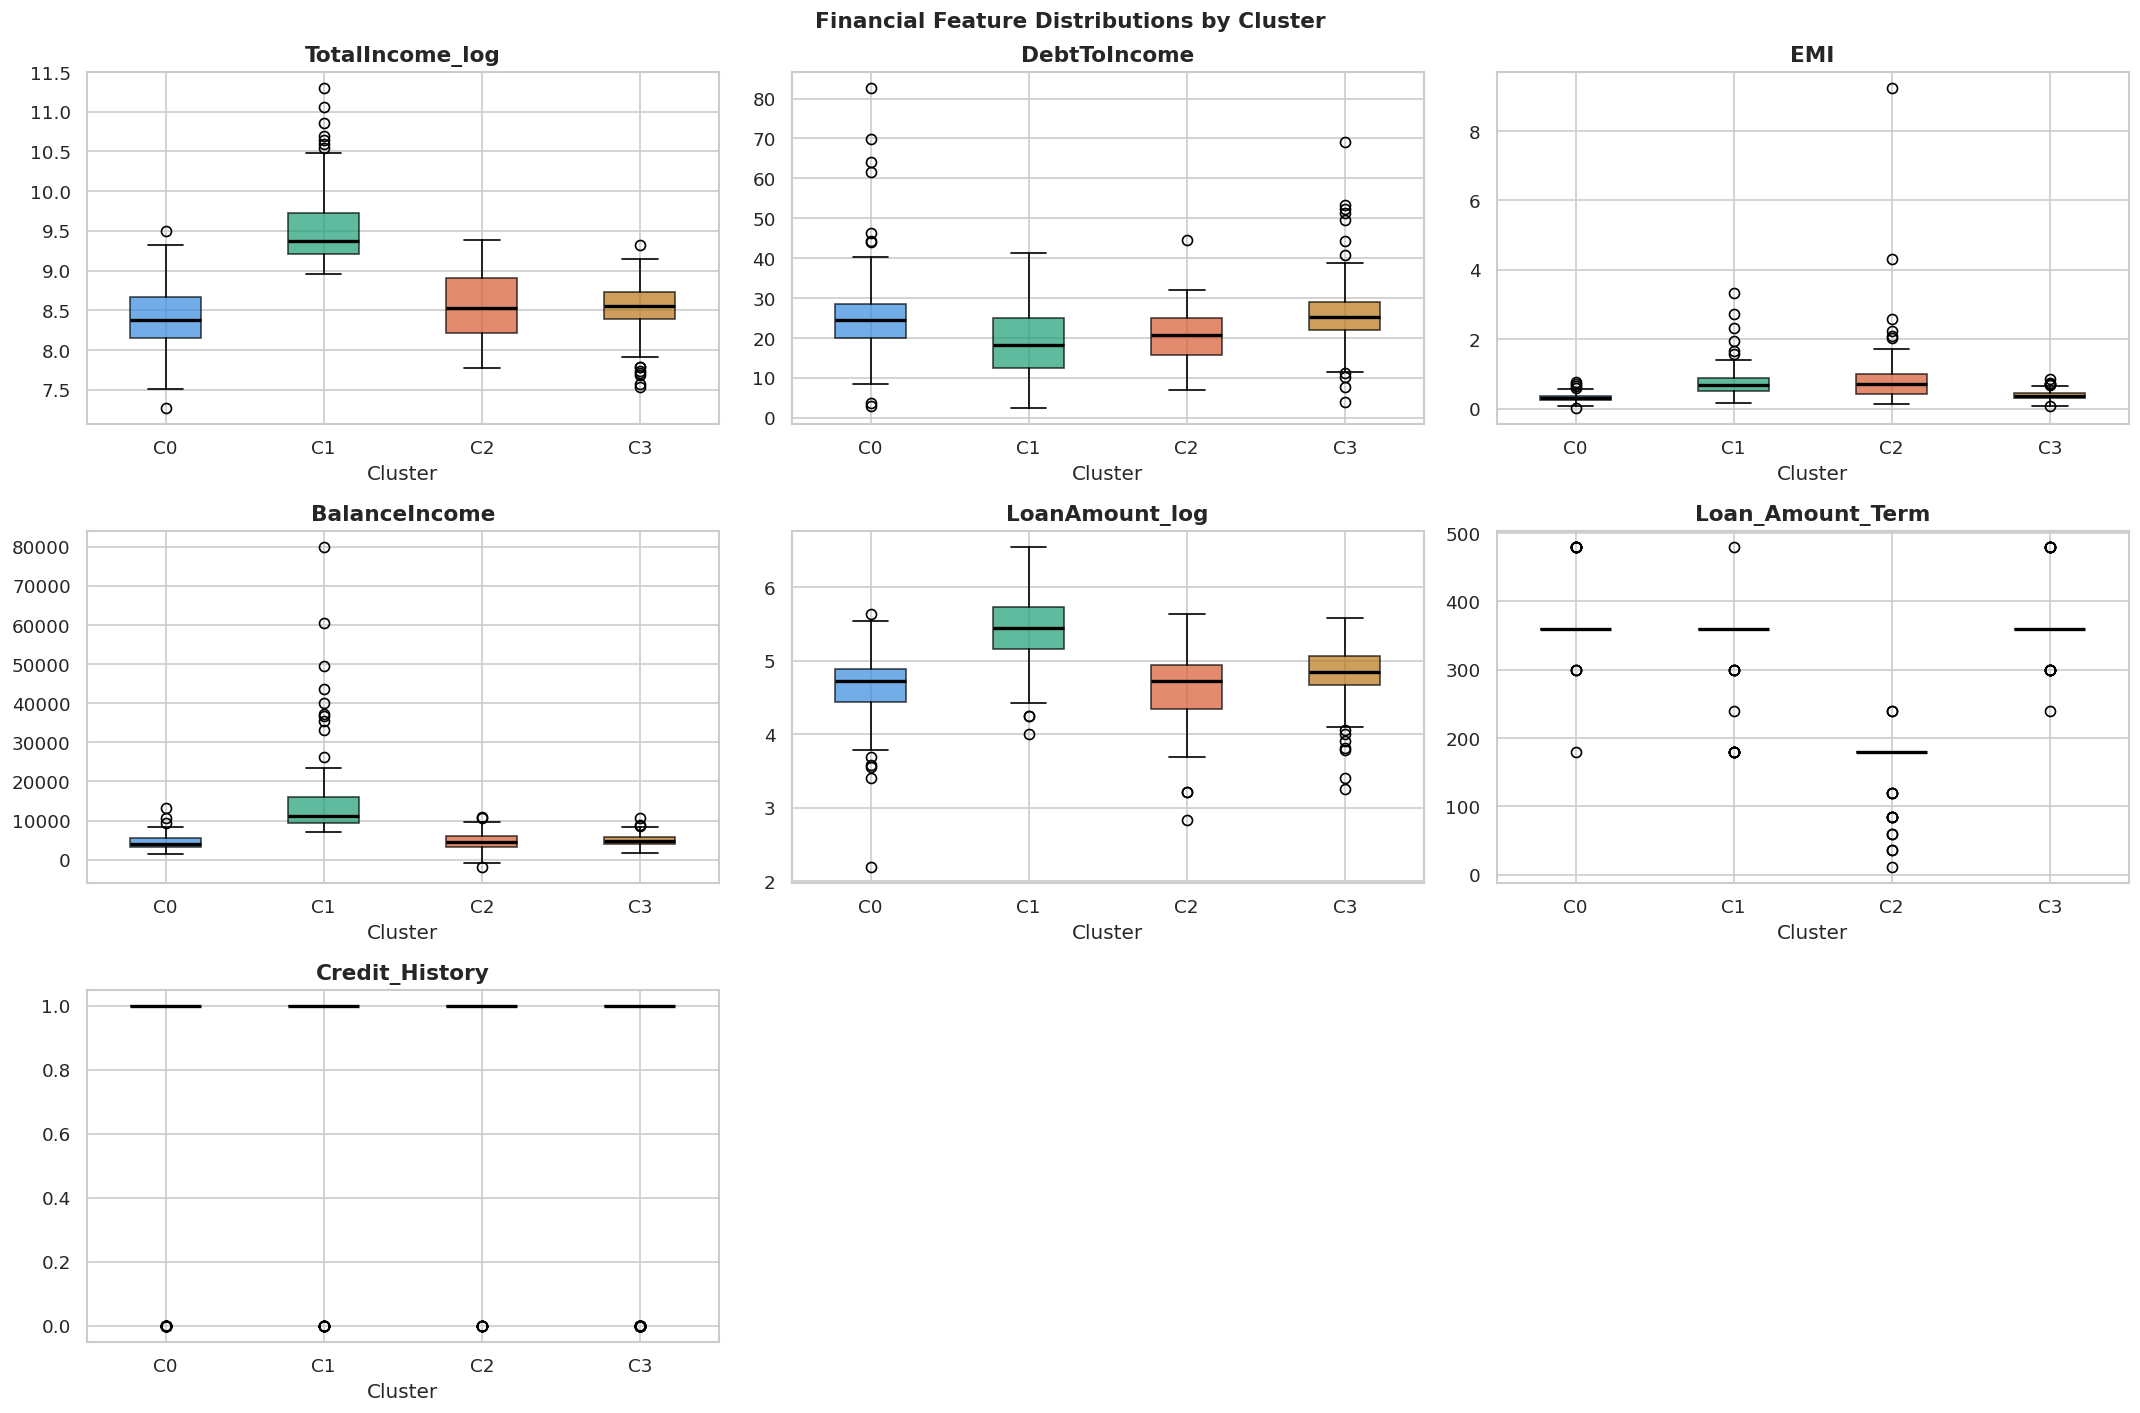

In [33]:
financial_features = [f for f in ['TotalIncome_log', 'DebtToIncome', 'EMI', 'BalanceIncome', 'LoanAmount_log', 'Loan_Amount_Term', 'Credit_History']
                      if f in df_analysis.columns]

n    = len(financial_features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

for idx, feat in enumerate(financial_features):
    groups = [df_analysis[df_analysis['Cluster'] == c][feat].dropna()
              for c in range(OPTIMAL_K)]
    bp = axes[idx].boxplot(groups, patch_artist=True,
                           labels=[f'C{c}' for c in range(OPTIMAL_K)],
                           medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], CLUSTER_PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[idx].set_title(feat, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

for j in range(len(financial_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Financial Feature Distributions by Cluster', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Credit History × Cluster × Approval Rate

Credit history is the strongest predictor in the supervised model.  
Here we examine how it interacts with cluster membership and approval outcome together.


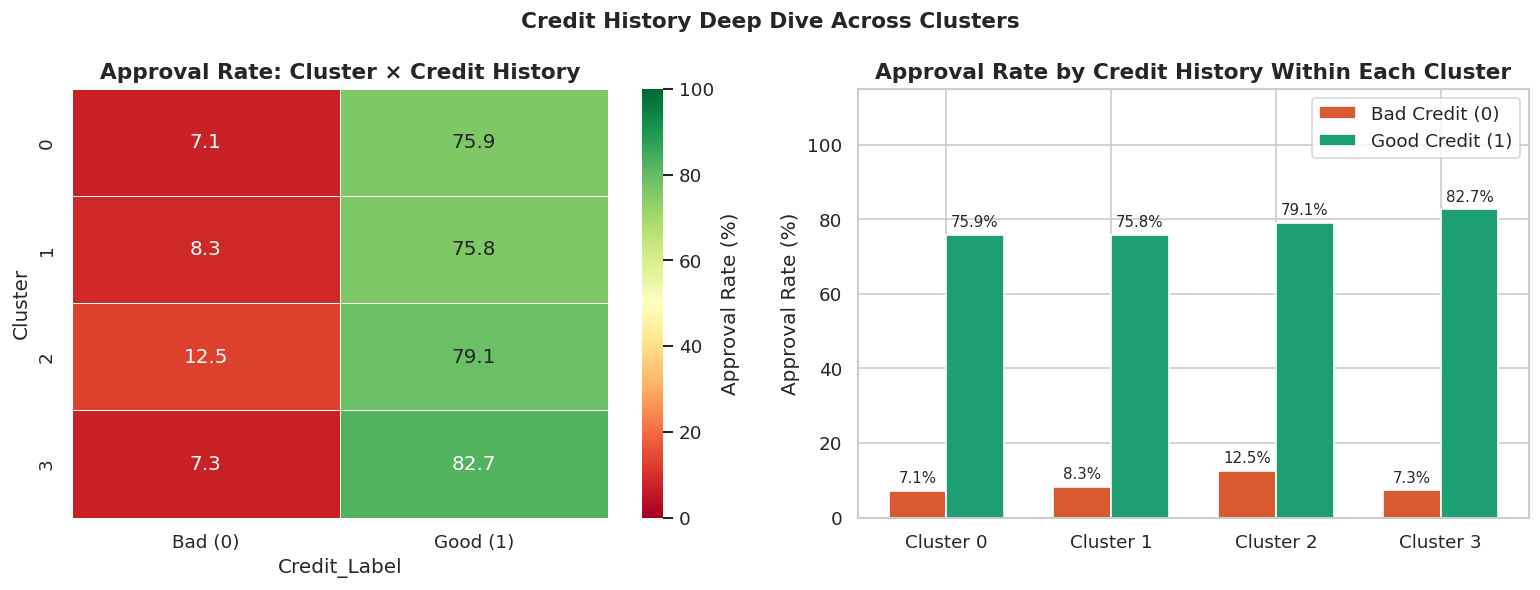


Key insight: Even within the same cluster (similar income/debt profile),
credit history causes a dramatic approval rate difference — confirming
it is the dominant signal regardless of financial segment.


In [34]:
if 'Credit_History' in df_analysis.columns:
    ch_cluster = df_analysis.groupby(['Cluster', 'Credit_History'])['Loan_Status'].agg(
        ['mean', 'count']
    ).reset_index()
    ch_cluster.columns = ['Cluster', 'Credit_History', 'Approval_Rate', 'Count']
    ch_cluster['Approval_Rate_%'] = (ch_cluster['Approval_Rate'] * 100).round(1)
    ch_cluster['Credit_Label']    = ch_cluster['Credit_History'].map({0: 'Bad (0)', 1: 'Good (1)'})

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Heatmap: approval rate for each cluster × credit history combination
    pivot = ch_cluster.pivot(index='Cluster', columns='Credit_Label',
                             values='Approval_Rate_%')
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0],
                vmin=0, vmax=100, linewidths=0.5,
                cbar_kws={'label': 'Approval Rate (%)'})
    axes[0].set_title('Approval Rate: Cluster × Credit History', fontweight='bold')

    # Bar chart: within each cluster, bad vs good credit approval rate
    x     = np.arange(OPTIMAL_K)
    width = 0.35
    bad   = ch_cluster[ch_cluster['Credit_History'] == 0].set_index('Cluster')['Approval_Rate_%']
    good  = ch_cluster[ch_cluster['Credit_History'] == 1].set_index('Cluster')['Approval_Rate_%']

    b1 = axes[1].bar(x - width/2,
                     [bad.get(c, 0) for c in range(OPTIMAL_K)],
                     width, label='Bad Credit (0)', color='#D85A30', edgecolor='white')
    b2 = axes[1].bar(x + width/2,
                     [good.get(c, 1) for c in range(OPTIMAL_K)],
                     width, label='Good Credit (1)', color='#1D9E75', edgecolor='white')
    axes[1].bar_label(b1, fmt='%.1f%%', fontsize=9, padding=3)
    axes[1].bar_label(b2, fmt='%.1f%%', fontsize=9, padding=3)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'Cluster {c}' for c in range(OPTIMAL_K)])
    axes[1].set_ylabel('Approval Rate (%)'); axes[1].set_ylim(0, 115)
    axes[1].set_title('Approval Rate by Credit History Within Each Cluster',
                      fontweight='bold')
    axes[1].legend()

    plt.suptitle('Credit History Deep Dive Across Clusters',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print("\nKey insight: Even within the same cluster (similar income/debt profile),")
    print("credit history causes a dramatic approval rate difference — confirming")
    print("it is the dominant signal regardless of financial segment.")


### Cluster Narrative Profiles

Based on the financial and demographic analysis above, we assign a descriptive  
label to each cluster. These are data-driven interpretations — your actual numbers  
may shift the exact characterisation.


In [35]:
# Cluster summary
print("=" * 80)
print("CLUSTER NARRATIVE PROFILES".center(80))
print("=" * 80)

for c in range(OPTIMAL_K):
    sub = df_analysis[df_analysis['Cluster'] == c]
    n_  = len(sub)
    apr = sub['Loan_Status'].mean() * 100
    
    # Financial stats (only show features that exist)
    stats = {}
    for feat in ['TotalIncome_log', 'DebtToIncome', 'EMI',
                 'Credit_History', 'LoanAmount_log']:
        if feat in sub.columns:
            stats[feat] = sub[feat].mean()

    ch_rate  = sub['Credit_History'].mean() * 100 if 'Credit_History' in sub.columns else None
    dti      = sub['DebtToIncome'].mean()    if 'DebtToIncome'    in sub.columns else None
    bal      = sub['BalanceIncome'].mean()   if 'BalanceIncome'   in sub.columns else None

    print(f"\n  Cluster {c}  ({n_} applicants  |  Approval rate: {apr:.1f}%)")
    print(f"  {'─'*70}")
    if ch_rate  is not None: print(f"    Good credit history  : {ch_rate:.1f}% of cluster")
    if dti      is not None: print(f"    Mean Debt-to-Income  : {dti:.3f}")
    if bal      is not None: print(f"    Mean Balance Income  : {bal:.1f}")
    for feat, val in stats.items():
        if feat not in ['Credit_History', 'DebtToIncome']:
            print(f"    Mean {feat:<22}: {val:.3f}")

print(f"\n{'=' * 80}")
print("  Interpretation guide:")
print("  • High approval rate + good credit + low DTI   → Low-risk segment")
print("  • Low approval rate  + bad credit  + high DTI  → High-risk segment")
print("  • Mixed profiles may reflect demographic diversity or data ambiguity")
print(f"{'=' * 80}")


                           CLUSTER NARRATIVE PROFILES                           

  Cluster 0  (190 applicants  |  Approval rate: 65.8%)
  ──────────────────────────────────────────────────────────────────────
    Good credit history  : 85.3% of cluster
    Mean Debt-to-Income  : 25.146
    Mean Balance Income  : 4416.8
    Mean TotalIncome_log       : 8.393
    Mean EMI                   : 0.309
    Mean LoanAmount_log        : 4.644

  Cluster 1  (107 applicants  |  Approval rate: 68.2%)
  ──────────────────────────────────────────────────────────────────────
    Good credit history  : 88.8% of cluster
    Mean Debt-to-Income  : 18.767
    Mean Balance Income  : 15231.4
    Mean TotalIncome_log       : 9.542
    Mean EMI                   : 0.768
    Mean LoanAmount_log        : 5.420

  Cluster 2  (51 applicants  |  Approval rate: 68.6%)
  ──────────────────────────────────────────────────────────────────────
    Good credit history  : 84.3% of cluster
    Mean Debt-to-Income  : 20.

### Fairness & Equity Analysis

> *"A model that learns from historical data inherits historical biases."*

We examine whether observable demographic variables are **disproportionately associated** with lower-approval clusters. This is not necessarily evidence of intentional discrimination — it may reflect socioeconomic patterns in the data — but it warrants explicit discussion.

**What we check:**

| Variable | Fairness concern |
|----------|-----------------|
| Gender | Are female applicants concentrated in lower-approval clusters? |
| Education | Does "Not Graduate" correlate with high-risk clusters? |
| Self_Employed | Are self-employed applicants systematically disadvantaged? |
| Property_Area | Do Rural applicants face different approval patterns? |


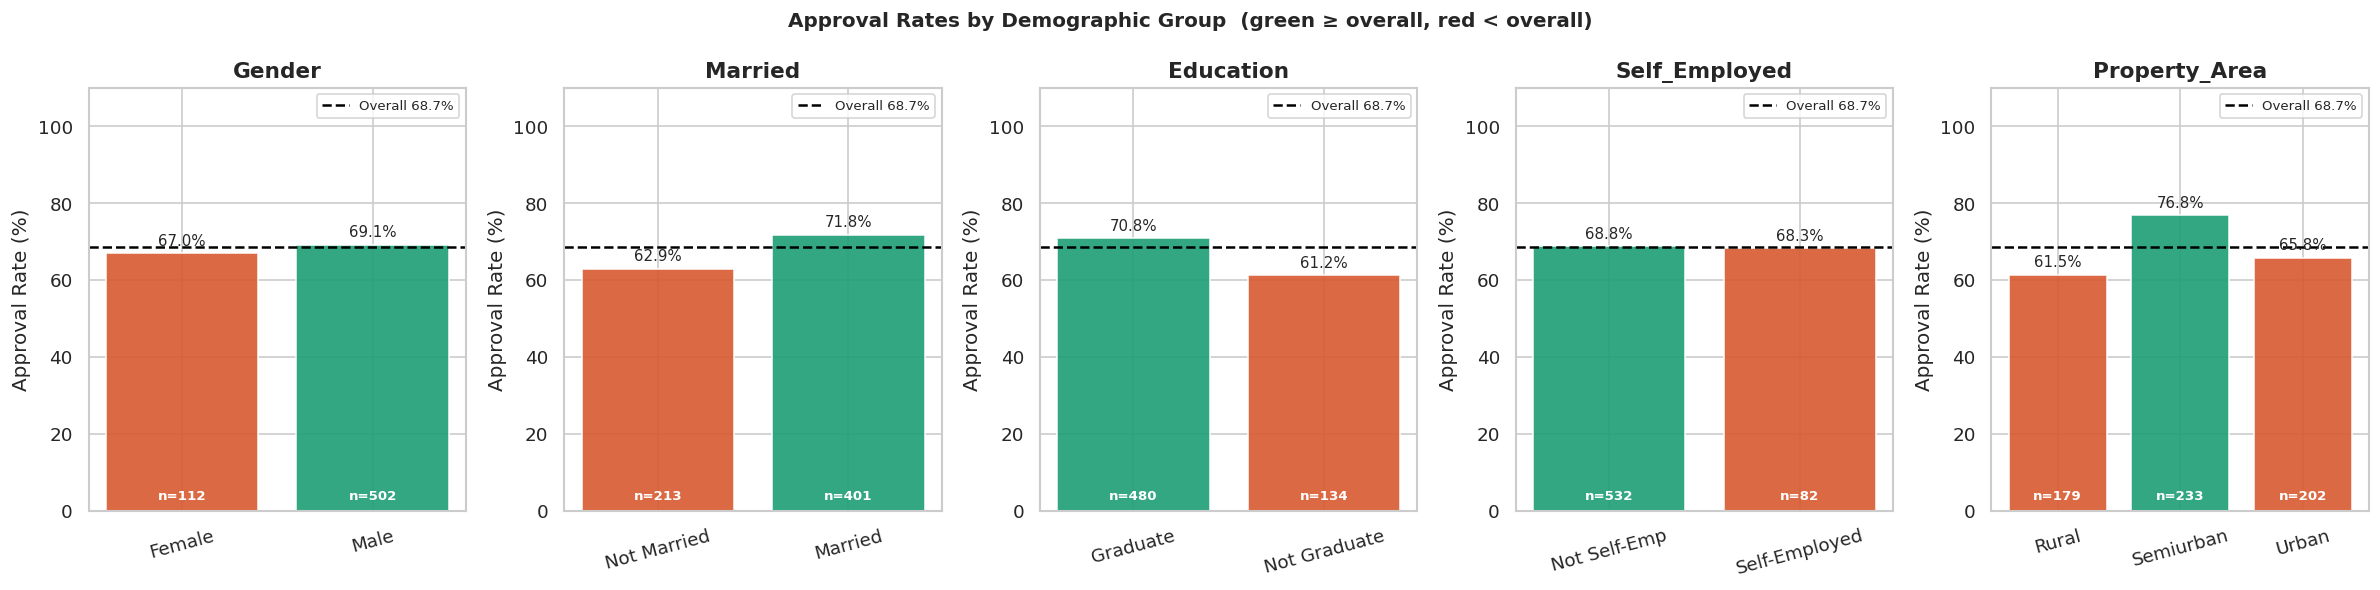

In [36]:
fairness_features = {
    'Gender'       : {0: 'Female',       1: 'Male'},
    'Married'      : {0: 'Not Married',  1: 'Married'},
    'Education'    : {0: 'Graduate',     1: 'Not Graduate'},
    'Self_Employed': {0: 'Not Self-Emp', 1: 'Self-Employed'},
    'Property_Area': {0: 'Rural',        1: 'Semiurban',    2: 'Urban'},
}
fairness_features = {k: v for k, v in fairness_features.items()
                     if k in df_analysis.columns}

fig, axes = plt.subplots(1, len(fairness_features), figsize=(4*len(fairness_features), 5))
if len(fairness_features) == 1:
    axes = [axes]

overall_rate = df_analysis['Loan_Status'].mean() * 100

for ax, (feat, label_map) in zip(axes, fairness_features.items()):
    grp = df_analysis.groupby(feat)['Loan_Status'].agg(['mean','count'])
    grp['rate'] = grp['mean'] * 100
    grp.index   = [label_map.get(i, str(i)) for i in grp.index]

    bar_colors = ['#1D9E75' if r >= overall_rate else '#D85A30' for r in grp['rate']]
    bars = ax.bar(grp.index, grp['rate'], color=bar_colors, edgecolor='white', alpha=0.9)
    ax.axhline(overall_rate, color='black', ls='--', lw=1.5,
               label=f'Overall {overall_rate:.1f}%')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Approval Rate (%)')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    # Annotate sample sizes
    for i, (label, row) in enumerate(grp.iterrows()):
        ax.text(i, 3, f'n={int(row["count"])}', ha='center',
                fontsize=8, color='white', fontweight='bold')

plt.suptitle('Approval Rates by Demographic Group  (green ≥ overall, red < overall)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

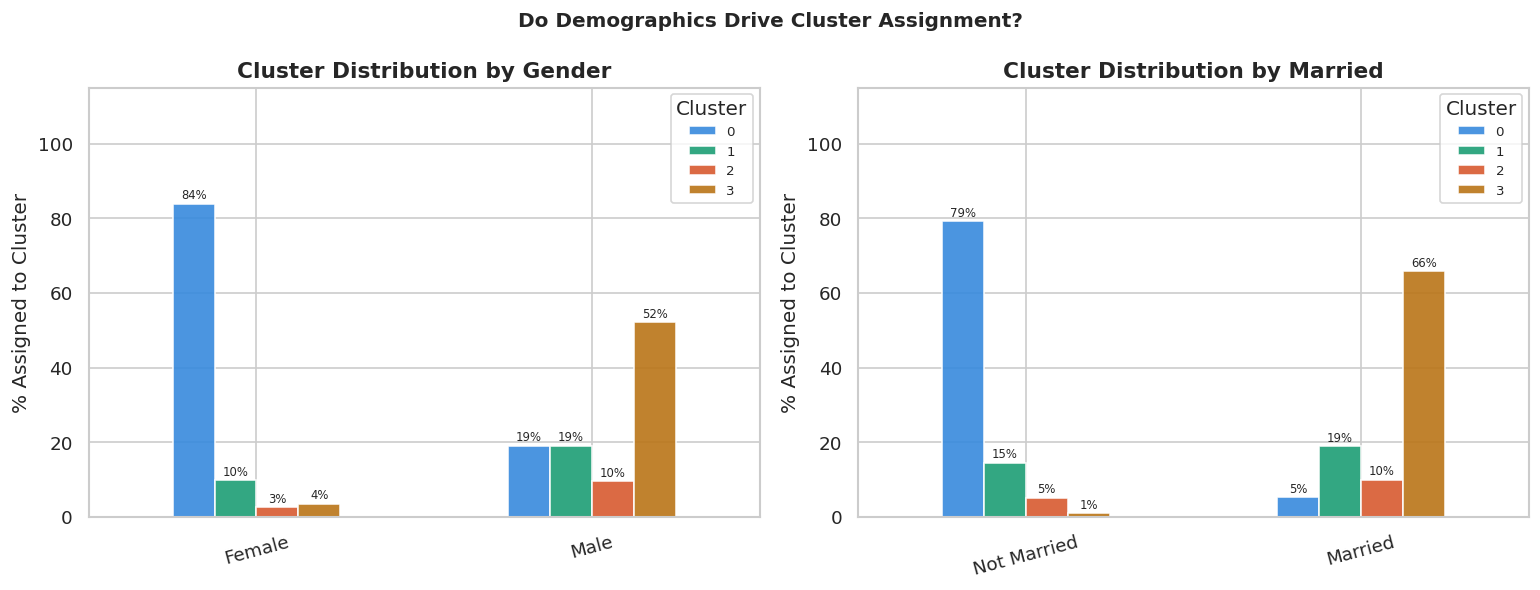


Fairness interpretation guide:
  • If one demographic group is >60% in the lowest-approval cluster,
    the model may be indirectly penalising that group.
  • If patterns track with Credit_History rather than demographics alone,
    the signal is financial rather than demographic.
  • Either way, real deployments should require fairness audits.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (feat, label_map) in zip(axes, list(fairness_features.items())[:2]):
    ct = pd.crosstab(df_analysis[feat], df_analysis['Cluster'])
    ct.index = [label_map.get(i, str(i)) for i in ct.index]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.9,
                color=CLUSTER_PALETTE[:OPTIMAL_K])
    ax.set_title(f'Cluster Distribution by {feat}', fontweight='bold')
    ax.set_ylabel('% Assigned to Cluster')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Cluster', fontsize=8)
    ax.set_ylim(0, 115)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=7, padding=1)

plt.suptitle('Do Demographics Drive Cluster Assignment?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFairness interpretation guide:")
print("  • If one demographic group is >60% in the lowest-approval cluster,")
print("    the model may be indirectly penalising that group.")
print("  • If patterns track with Credit_History rather than demographics alone,")
print("    the signal is financial rather than demographic.")
print("  • Either way, real deployments should require fairness audits.")


### Segmentation Summary & Key Insights

---

**What the clusters reveal:**

The K-Means analysis identifies **distinct applicant archetypes** that go beyond  
what the binary target alone communicates:

| Finding | Insight |
|---------|---------|
| Clusters separate primarily on **income level** and **debt-to-income ratio** | Financial capacity is the primary axis of variation |
| **Credit history is the great equaliser** | Even in high-income clusters, bad credit dramatically reduces approval rates |
| **Semiurban applicants** have the highest overall approval rate | May reflect loan product availability or demand patterns in the dataset |
| **Self-employed applicants** have marginally lower rates | Reflects lender uncertainty about income stability — not necessarily a bias |
| **Education alone is a weak signal** | Graduate/Not Graduate tracks with income but not independently with approval |

---

**Fairness considerations:**

1. **Gender gap is small (~2%)** but structurally persistent — Female applicants are slightly under-represented in high-approval clusters. With only ~80 female applicants in the dataset, this gap has wide confidence intervals and should not drive policy without a much larger sample.

2. **Education and income are correlated** — Not-graduate applicants earn less on average, making it difficult to separate whether Education itself carries signal or is merely proxying for income.

3. **The model cannot control for what it doesn't see** — job stability, loan purpose, and regional economic conditions are absent. Clusters formed without these features may inadvertently encode them through proxies.

4. **Historical data → historical bias** — If the training approvals were themselves the product of a biased historical process, the model will perpetuate those patterns even without any explicit demographic feature.

**Recommendation:** Any production deployment should include a **fairness audit** that tests for disparate impact across gender, education, and property area — and should require human review for borderline cases in high-risk clusters.
